In [2]:
import polars as pl
from pathlib import Path
import json
import os
import matplotlib.pyplot as plt

from gena_expression.dna.genome import Genome
from gena_expression.inference.model import SequenceModel
from gena_expression.conditions import Condition, DescriptionLookup, _temporary_sys_path
from gena_expression.tracks import Track

In [ ]:
# Paths and constants used by later cells

from pathlib import Path

GENALM_HOME = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark")

os.environ["GENALM_HOME"] = GENALM_HOME.__str__()

GENA_LM_ROOT = GENALM_HOME / "GENA_LM" # CHANGE THIS LINE

EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_FILE = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_FILE}::ExpressionCounts"

MODEL_CHECKPOINT = GENALM_HOME / "models" / "expression_model_v1-1" / "pytorch_model.bin" # CHANGE THIS LINE
MODEL_CONFIG = EXPRESSION_TASK_DIR / 'configs' / "final.yaml" # CHANGE THIS LINE
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

DATA_DIR = Path("../data").resolve()
DESCRIPTION_DIR = DATA_DIR / "real_descriptions"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa") # CHANGE THIS LINE
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
) # CHANGE THIS LINE

DEVICE = "cuda:5" # CHANGE THIS LINE


TOKEN_LEN_FOR_FETCH = 20
NUM_BEFORE = 511
DNA_MAX_SEQ_LEN = 1024
DESC_MAX_SEQ_LEN = 510

In [ ]:
model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=DNA_MAX_SEQ_LEN,
    num_before=NUM_BEFORE,
    desc_max_seq_len=DESC_MAX_SEQ_LEN,
    token_len_for_fetch=TOKEN_LEN_FOR_FETCH,
    device=DEVICE,
)

/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/inference/model.py:172: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):
Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

Rattus_norvegicus

In [ ]:
BASE_DIR = Path('/home/jovyan/estsoi/SRS10105303')
FILTERED_INTEVALS_BASE = Path('/workspace-SR003.nfs2/estsoi/blast_filtered_cre_intervals')
INTERVALS_BASE = Path('/workspace-SR003.nfs2/estsoi/unprocessed_intervals')

#ALL INTERVALS, WITHOUT SELECTION
intervals_forward = pl.read_csv(INTERVALS_BASE / 'Rattus_norvegicus.csv').sort('cre_prob', descending=True)
intervals_reverse = pl.read_csv(INTERVALS_BASE / 'Rattus_norvegicus.csv').sort('cre_prob', descending=True)

#SELECTED INTERVALS WITH BLAST, FROM TRAIN
intervals_forward_filtered = pl.read_csv(BASE_DIR / 'Rattus_norvegicus_forward.csv').sort('cre_prob', descending=True)
intervals_reverse_filtered = pl.read_csv(BASE_DIR / 'Rattus_norvegicus_reverse.csv').sort('cre_prob', descending=True)

bw_forward = BASE_DIR / 'SRS10105303.forward.bw'
bw_reverse = BASE_DIR / 'SRS10105303.reverse.bw'
bw_forward_qnorm = BASE_DIR / 'SRS10105303.forward.qnorm.bw'
bw_reverse_qnorm = BASE_DIR / 'SRS10105303.reverse.qnorm.bw'
description = json.load(
                            open(BASE_DIR / 'SRS10105303.json', 'r')
                        )
genome_fasta = BASE_DIR / 'Rattus_norvegicus.fasta'
genome_annotation = BASE_DIR / 'GCF_036323735.1_GRCr8_genomic.gtf.gz'

In [ ]:
#FIND INTERVALS THAT ARE NOT IN TRAIN 
#RUN INFERENCE FOR THEM, FOR TWO SPECIES, AS SHOWN BELOW

In [11]:
intervals_reverse_filtered.__len__()

20000

In [12]:
intervals_reverse.__len__()

445040

In [ ]:
#diff = intervals_forward.join(intervals_forward_filtered, on=intervals_forward.columns, how="anti")

In [ ]:
intervals_forward = diff.sort('cre_prob', descending=True)

In [105]:
genome = Genome(fasta_path = genome_fasta, annotation=genome_annotation)

/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/dna/genome.py:490: RuntimeWarning: Could not index the provided annotation; using existing sorted annotation. debug={'compressed_path': '/home/jovyan/estsoi/SRS10105303/GCF_036323735.1_GRCr8_genomic.gtf.gz', 'sorted_path': '/home/jovyan/estsoi/SRS10105303/GCF_036323735.1_GRCr8_genomic.sorted.gtf.gz', 'original_error': 'original annotation has no tabix index and a sorted copy already exists'}
  return cls._sort_and_index_gtf(


In [106]:
top_10 = intervals_forward.head(30)
middle_10 = intervals_forward[len(intervals_forward)//2-7000-5:len(intervals_forward)//2-7000+5, :]
bottom_10 = intervals_forward.tail(10)

In [107]:
top_10

gene_id,chromosome,TSS,TES,cre_prob
str,str,i64,i64,f64
"""cre_15150_fwd""","""NC_086032.1""",12073355,12079768,0.999936
"""cre_9092_fwd""","""NC_086025.1""",109983614,109989952,0.999744
"""cre_15123_fwd""","""NC_086032.1""",11759984,11766399,0.999398
"""cre_15132_fwd""","""NC_086032.1""",11881574,11887951,0.999274
"""cre_15145_fwd""","""NC_086032.1""",12028551,12034930,0.999174
…,…,…,…,…
"""cre_10859_fwd""","""NC_086026.1""",132059300,132065666,0.936531
"""cre_5265_fwd""","""NC_086022.1""",18054444,18060918,0.935696
"""cre_17418_fwd""","""NC_086036.1""",31718867,31725329,0.935635


In [108]:
tss_tes_coords_top_10 = {row['gene_id'] : (row['chromosome'], row['TSS'], row['TES'], '+') for row in top_10.iter_rows(named=True)}

In [109]:
results = []

sequences = []
for gene, (chrom, tss, tes, strand) in tss_tes_coords_top_10.items():
    sequence = genome.sequence(
            chrom=chrom,
            start=tss,
            end=tes,
            strand=strand,
            include_features=True,
            name=gene,
        )
    sequences.append(sequence)

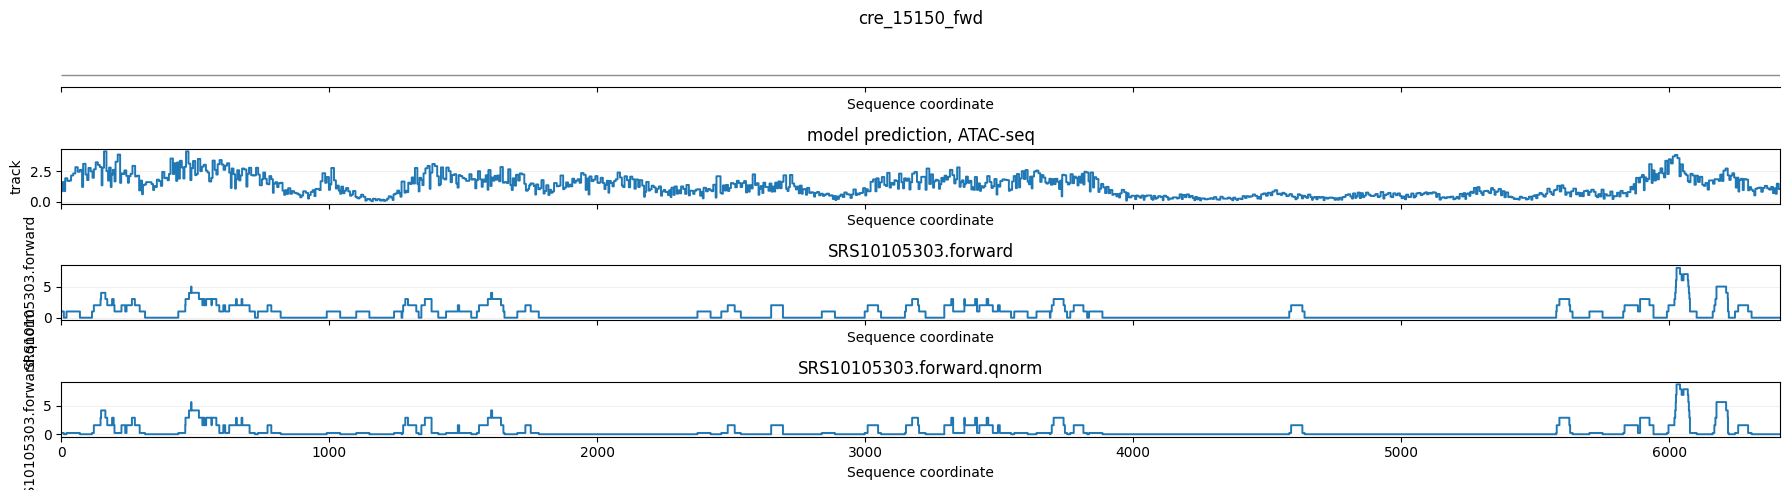

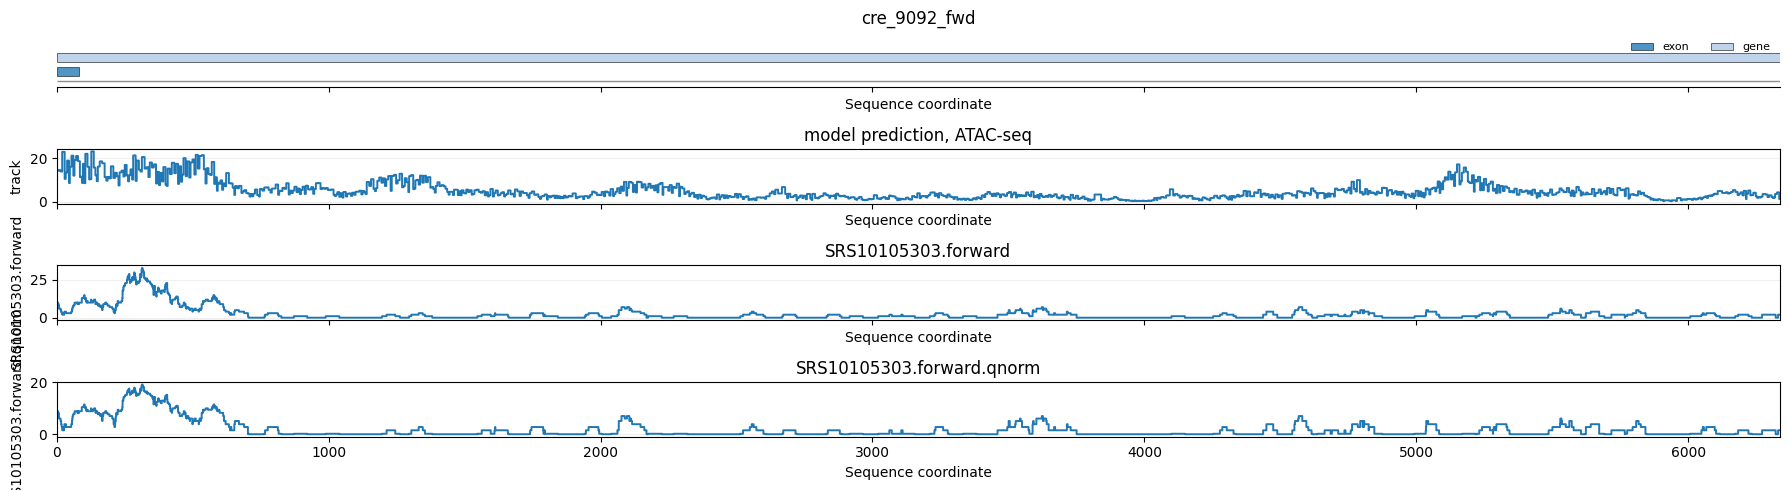

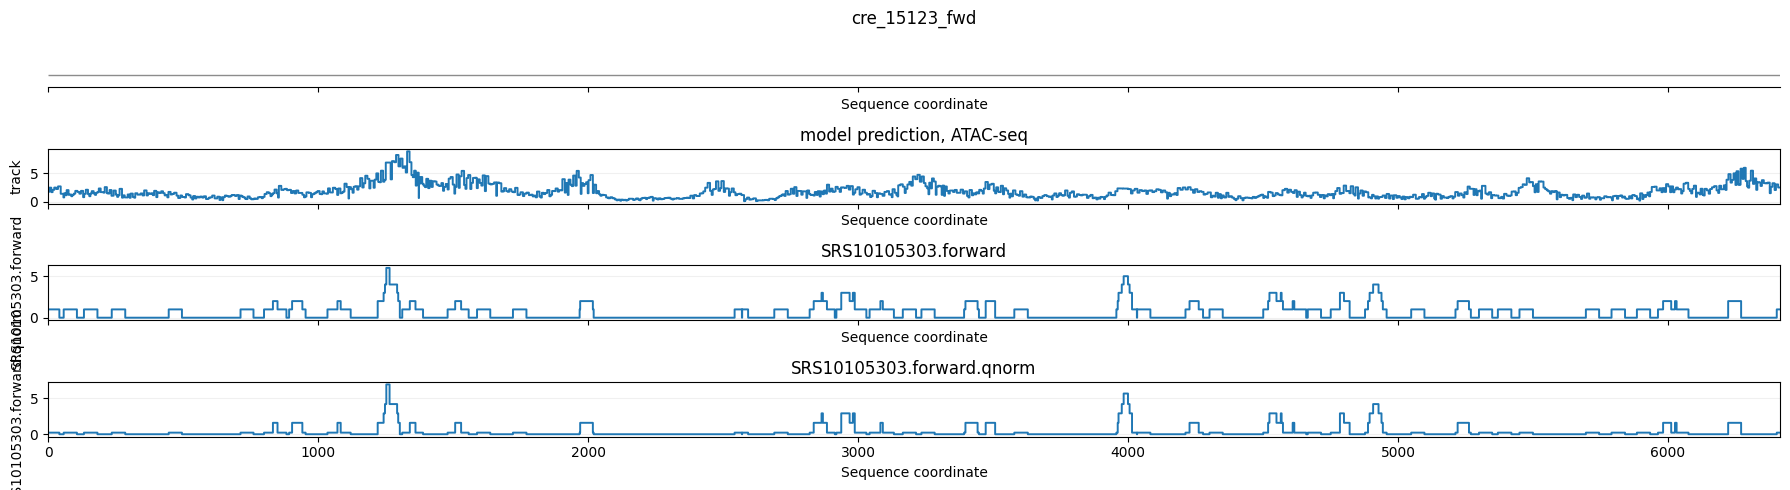

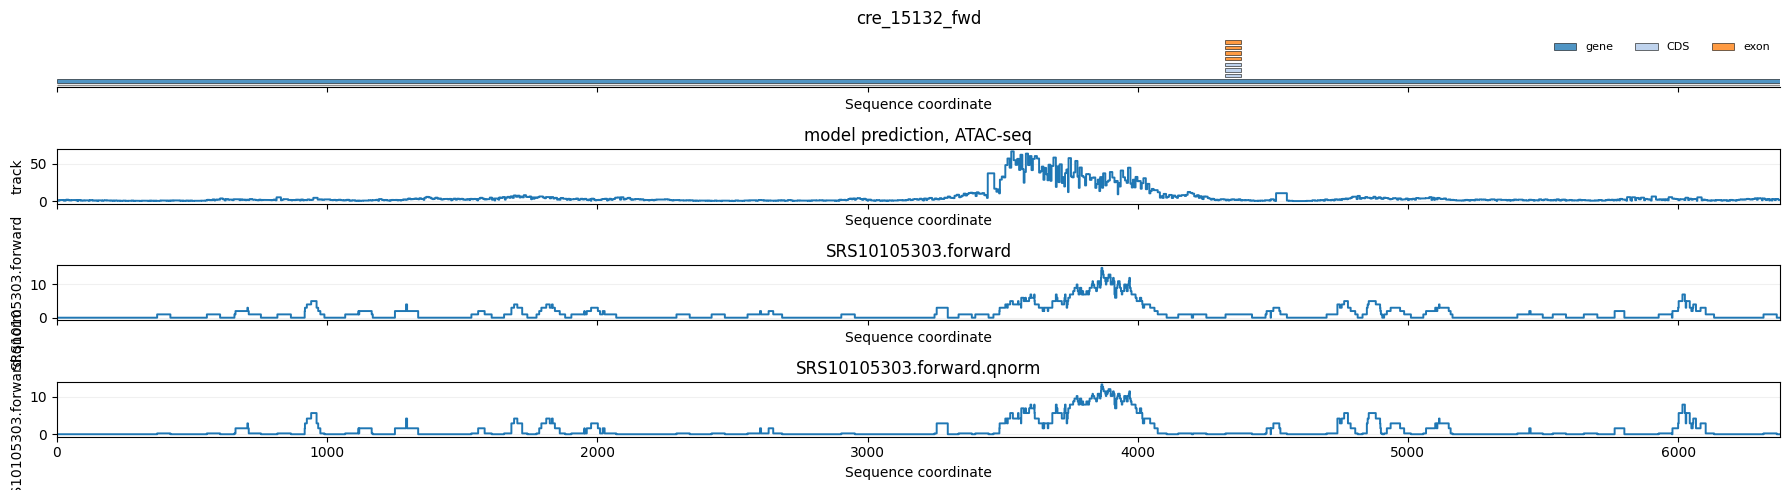

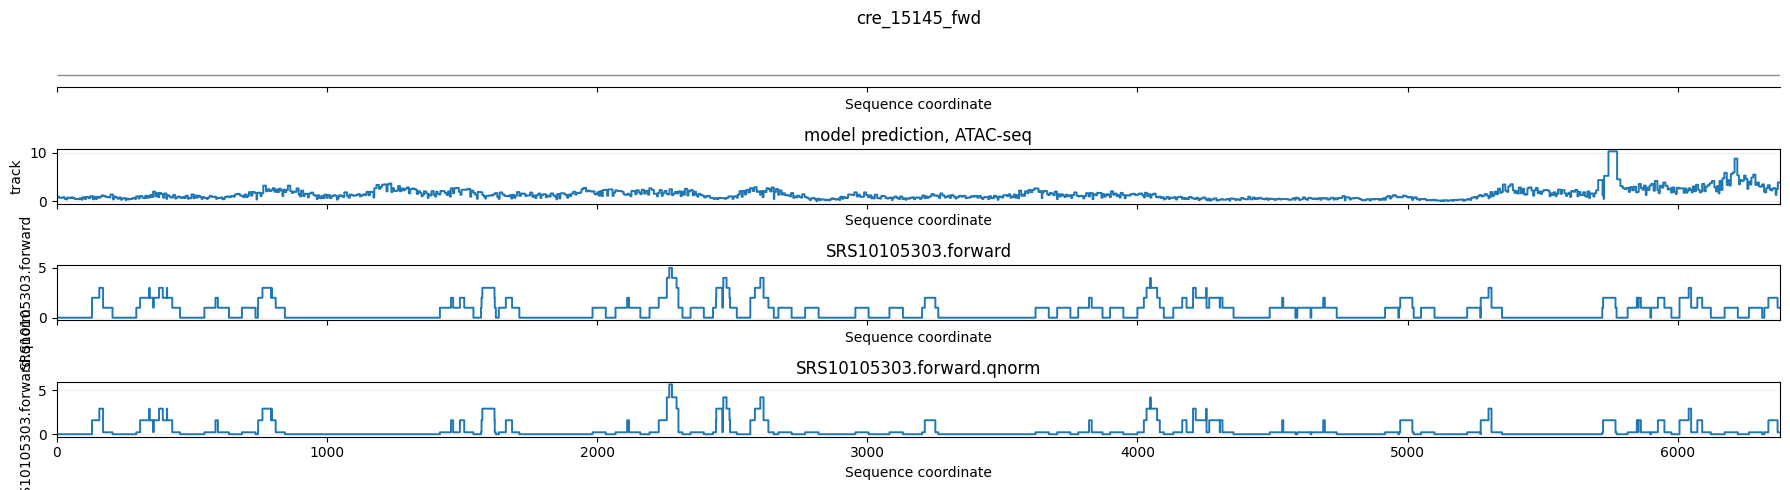

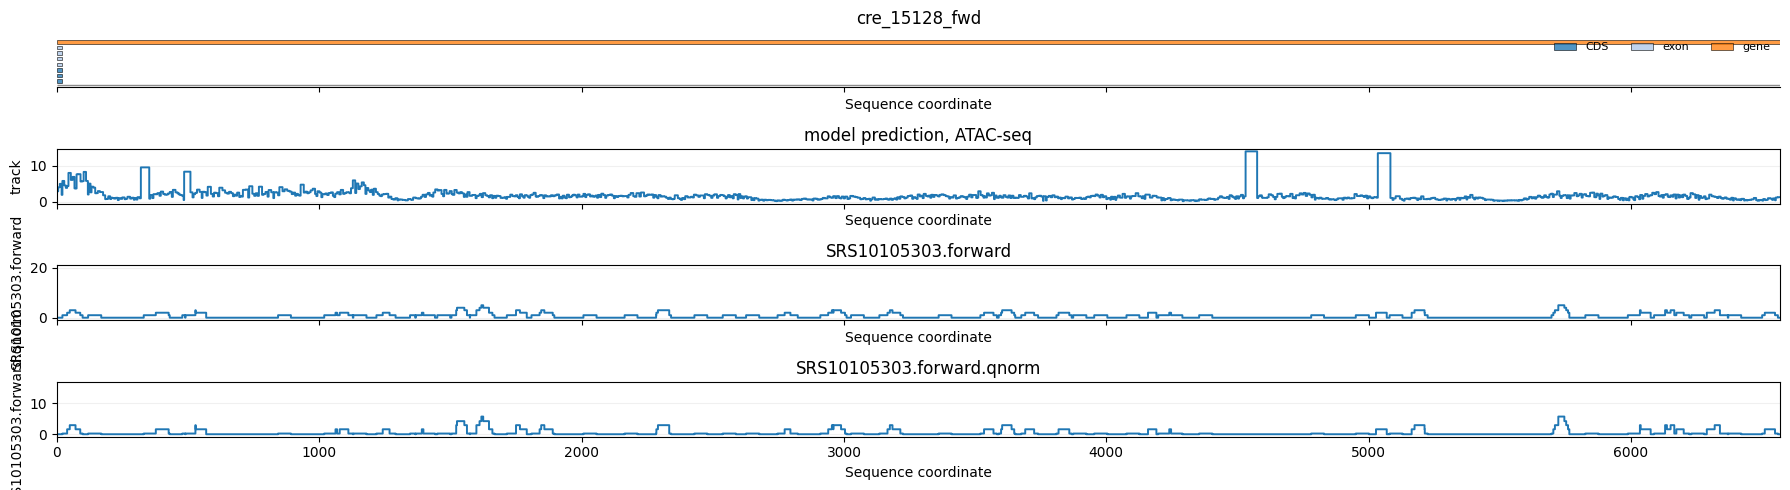

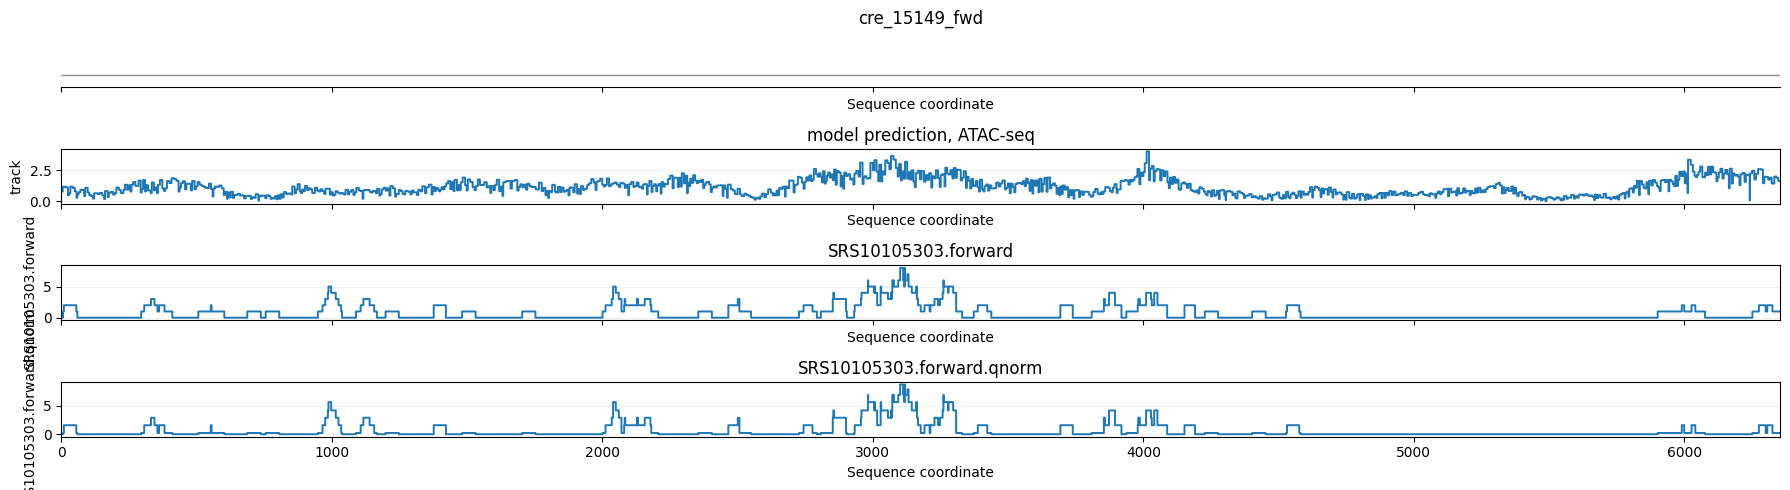

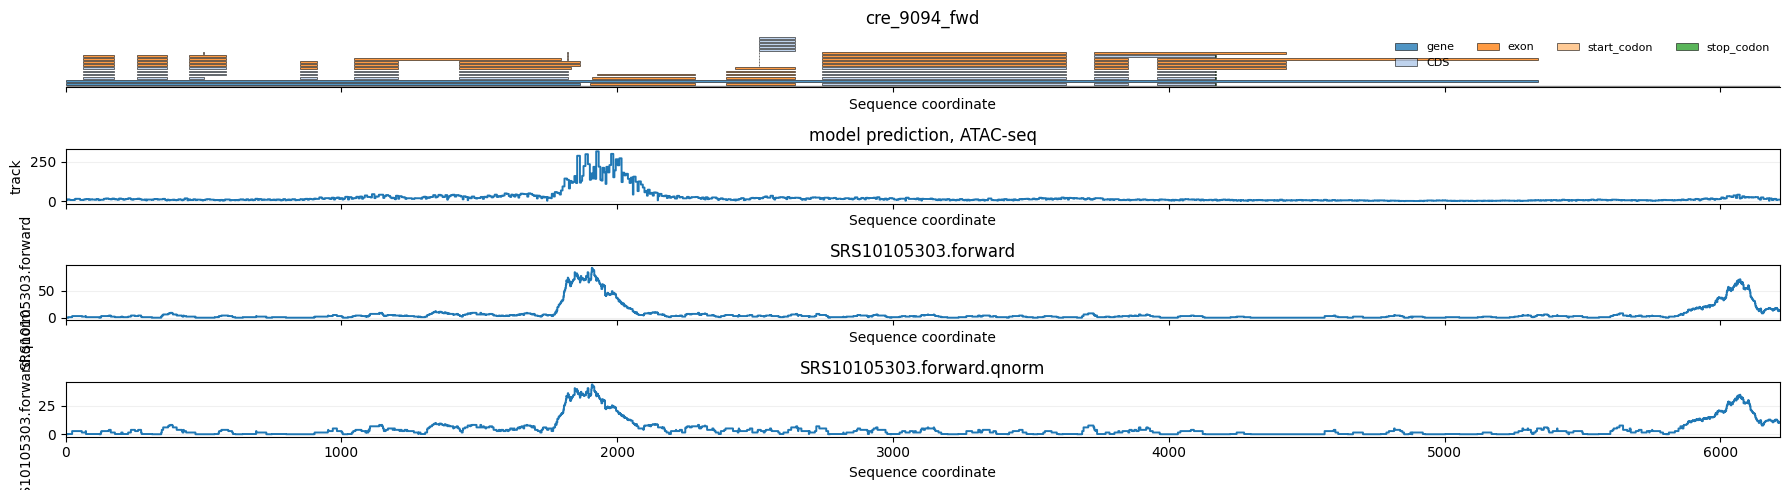

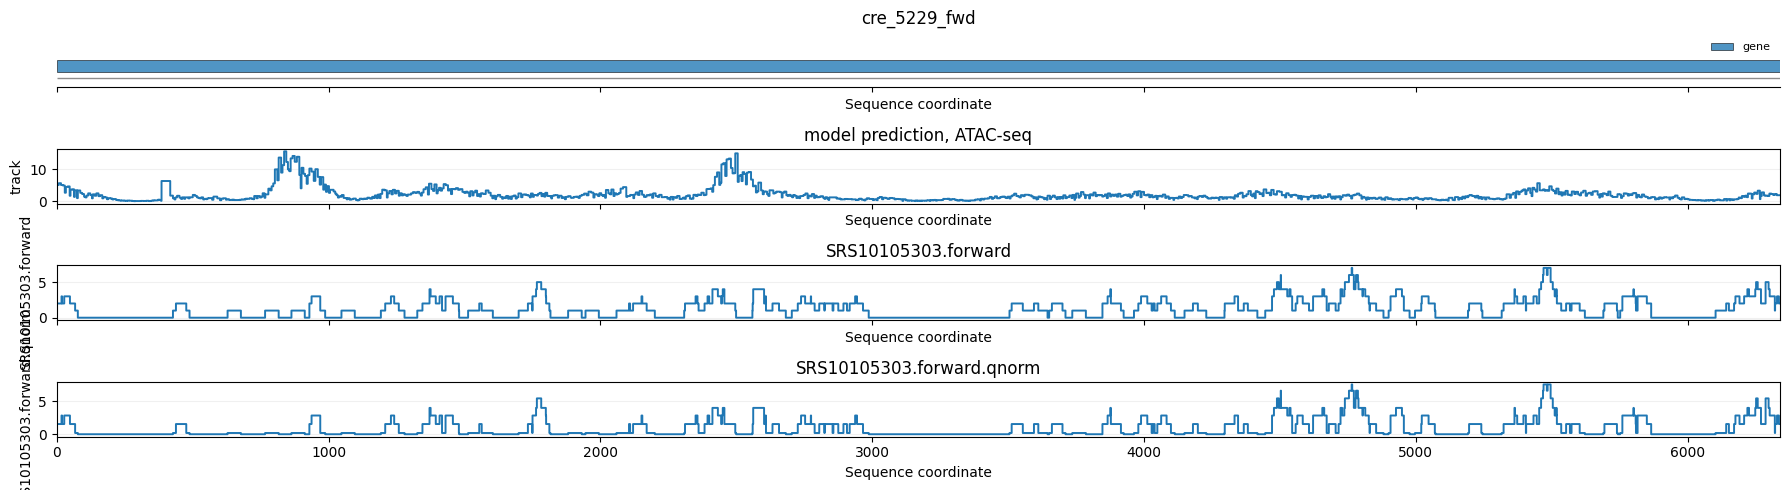

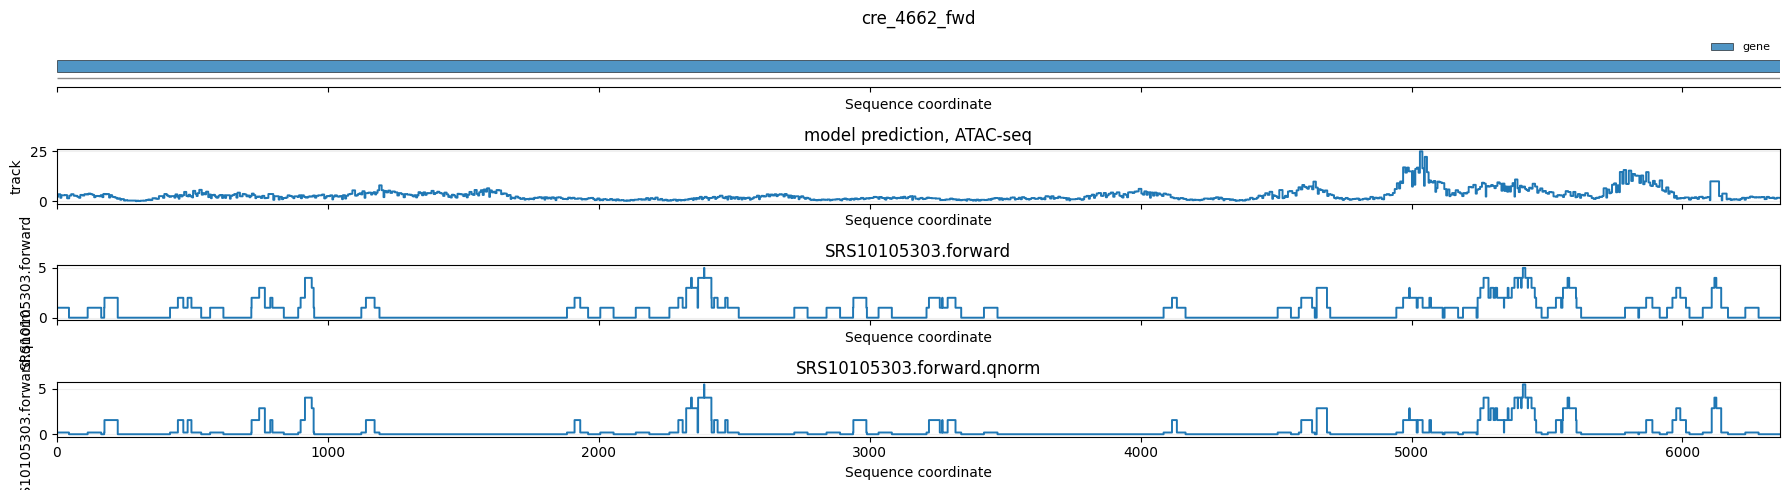

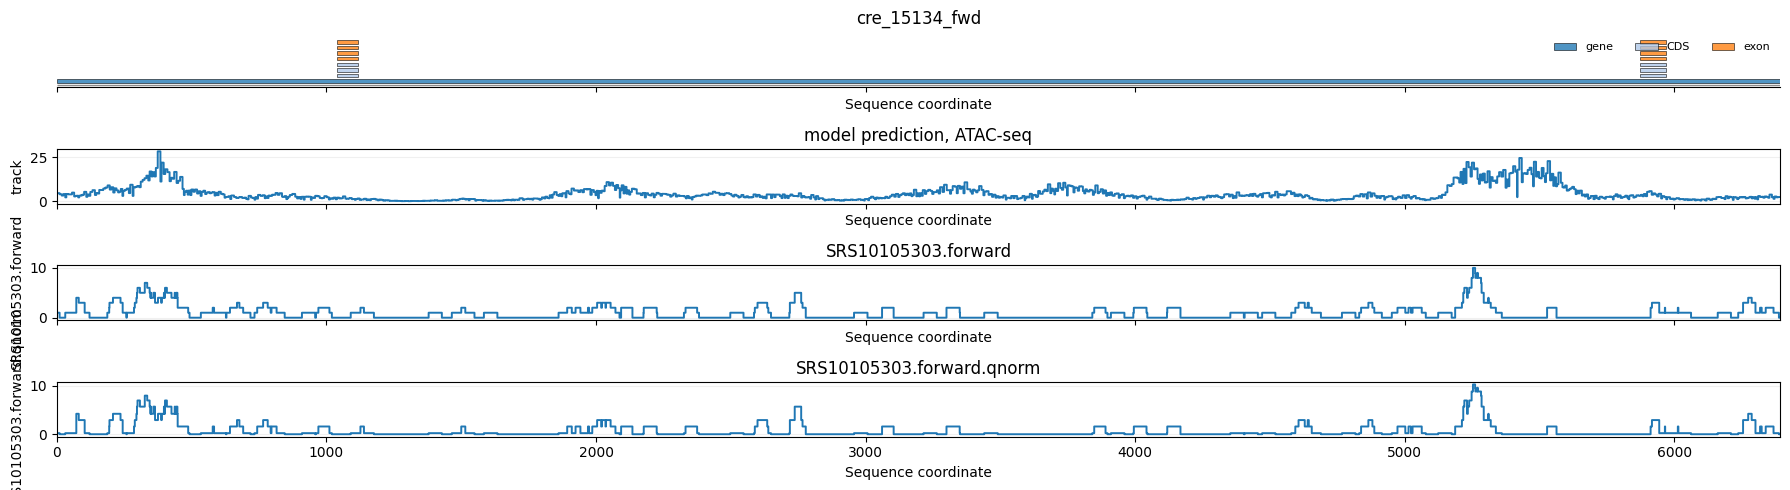

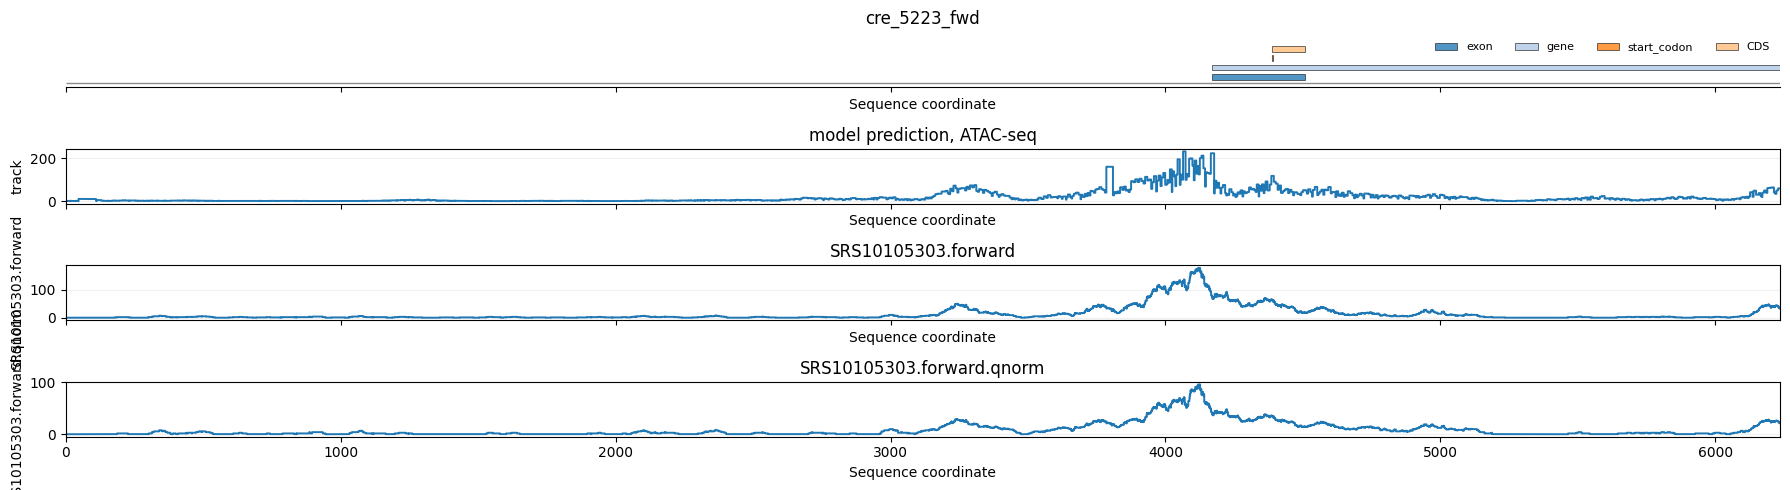

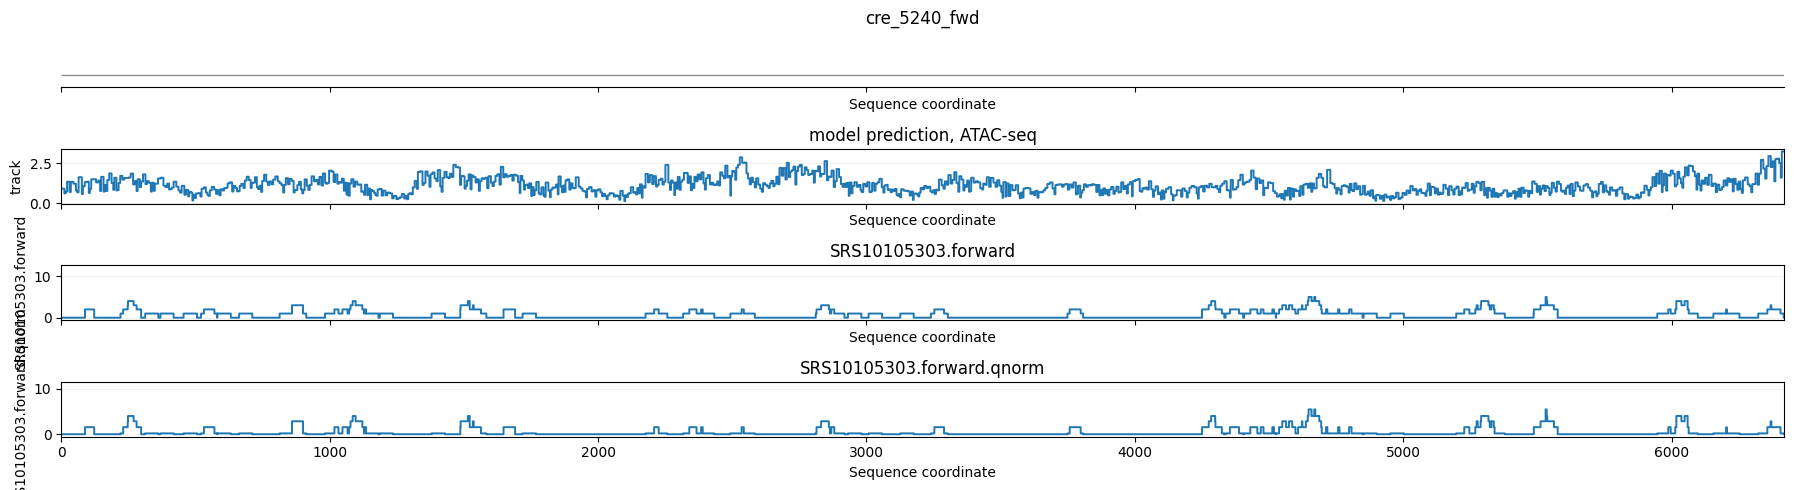

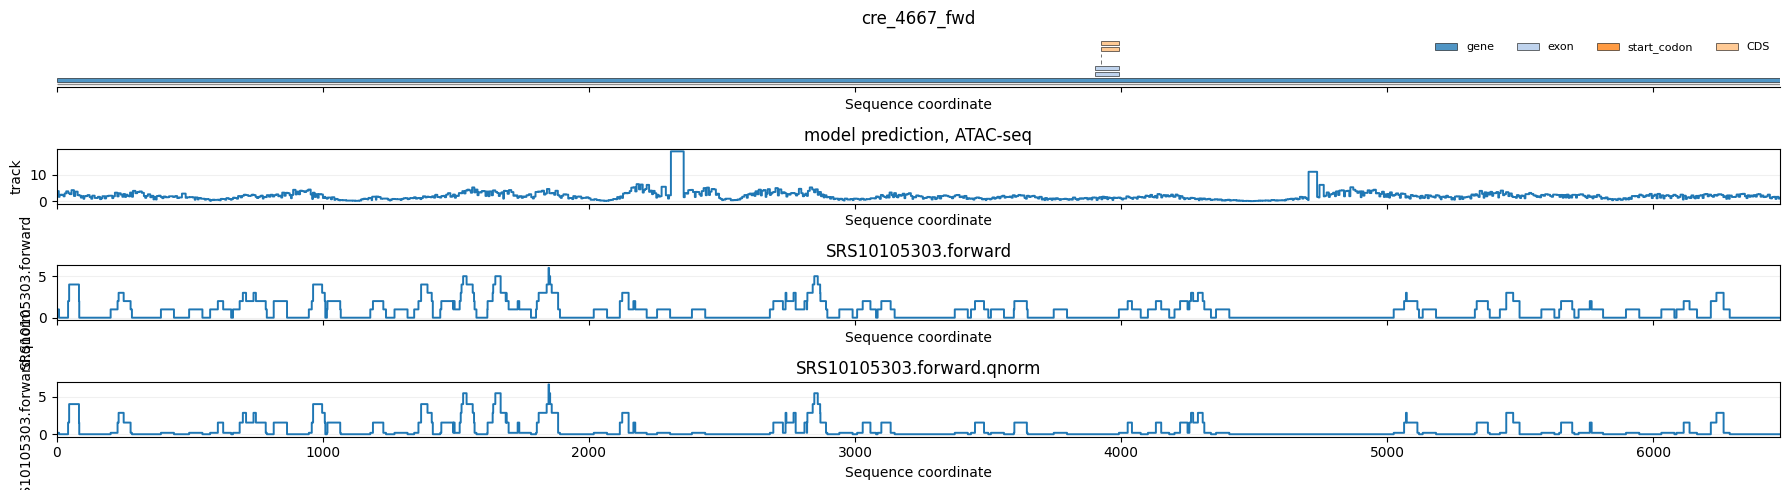

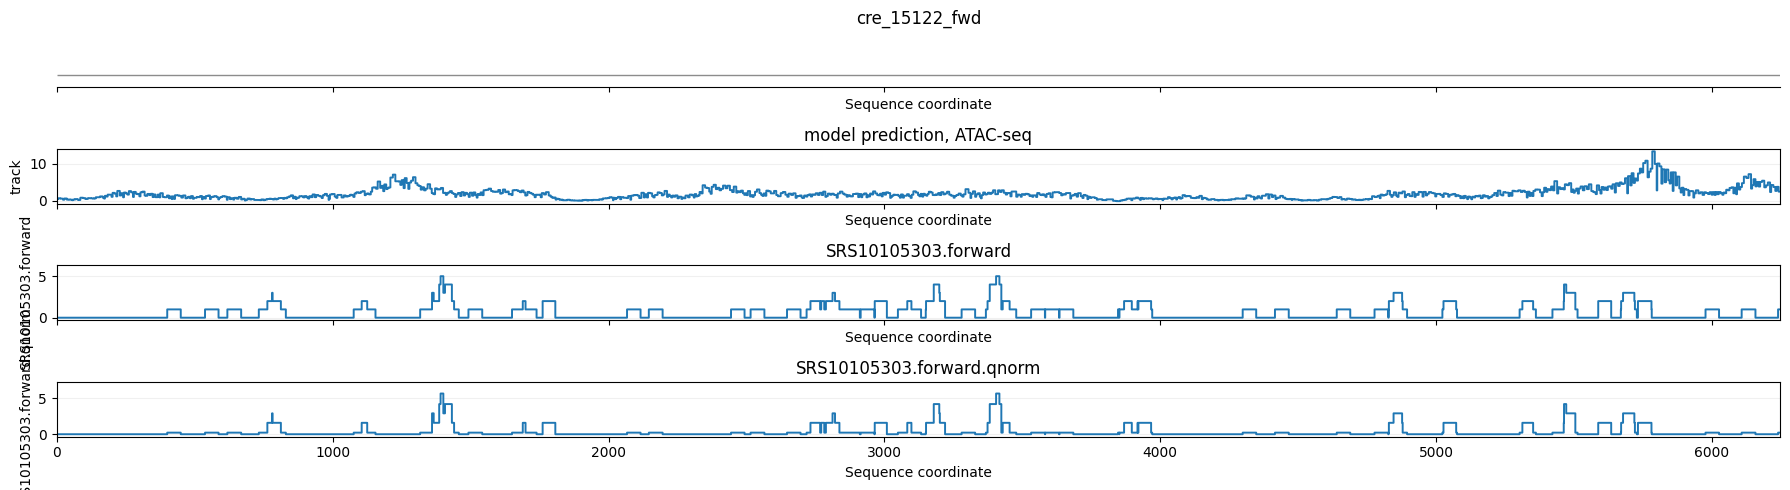

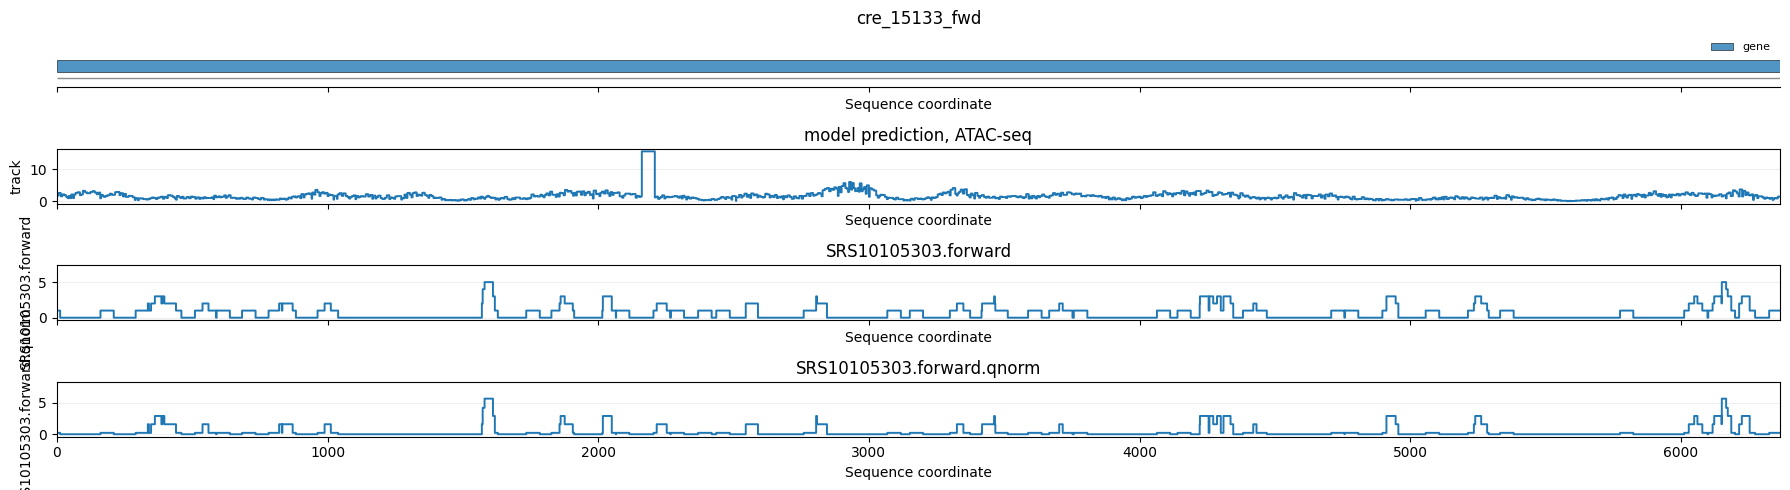

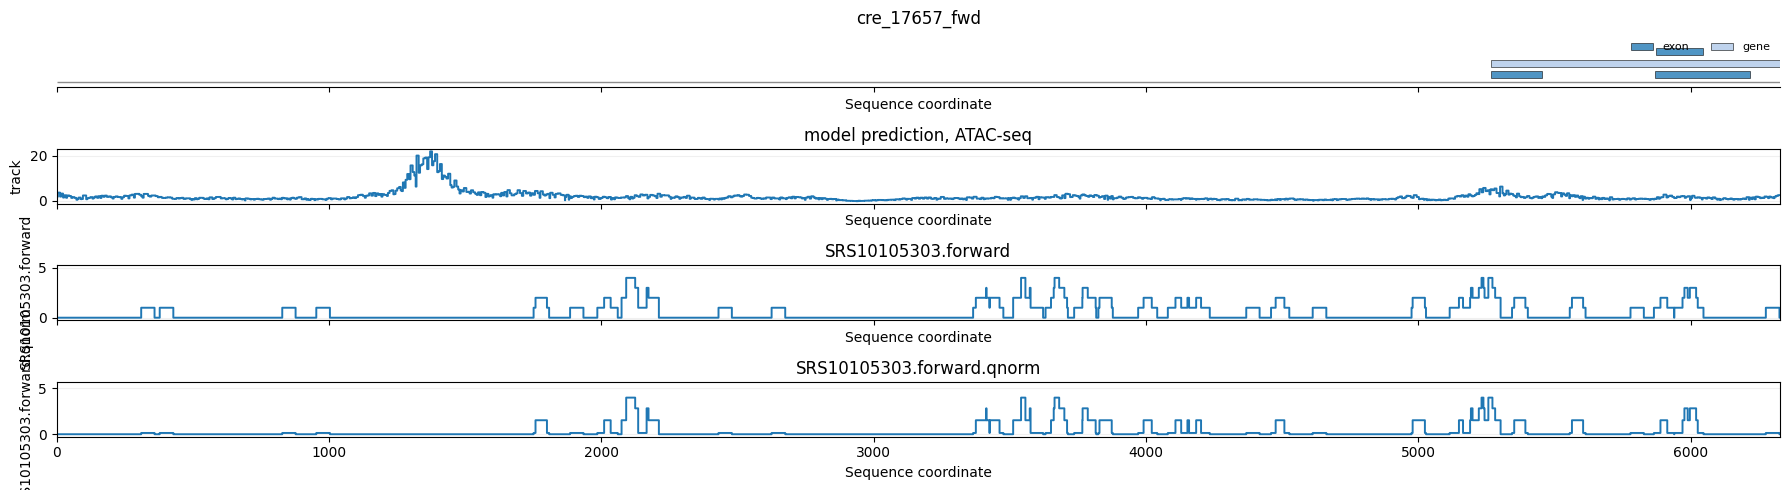

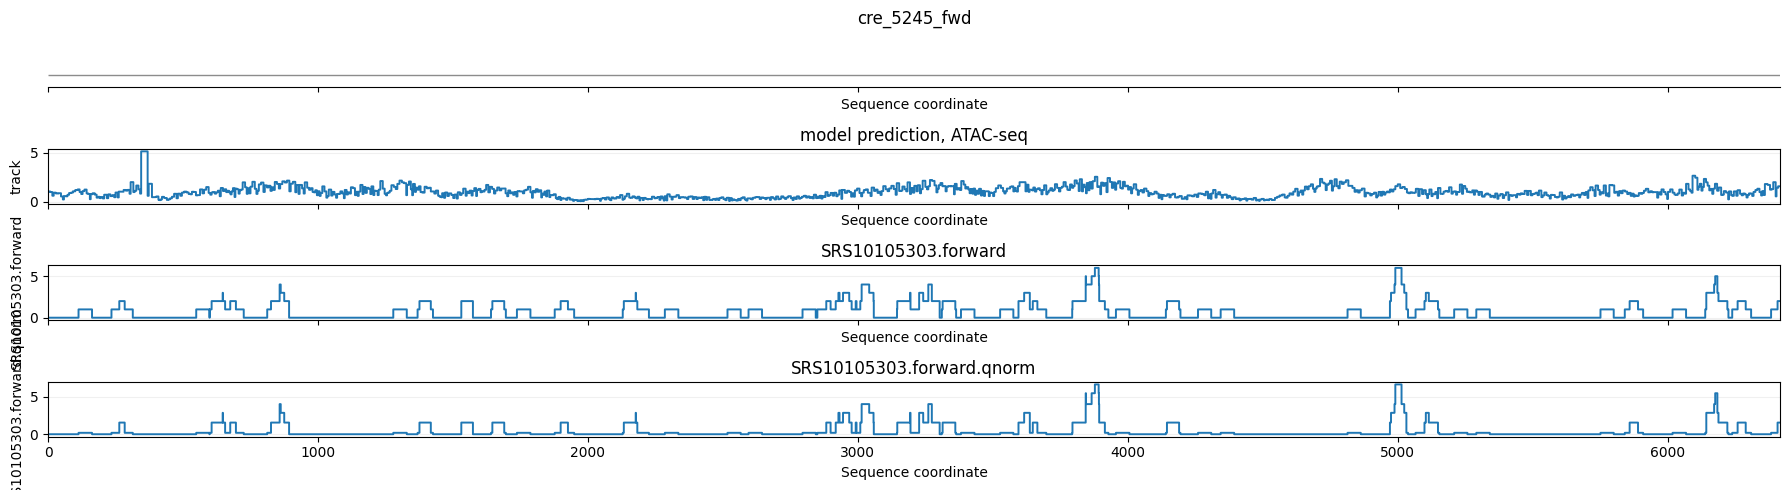

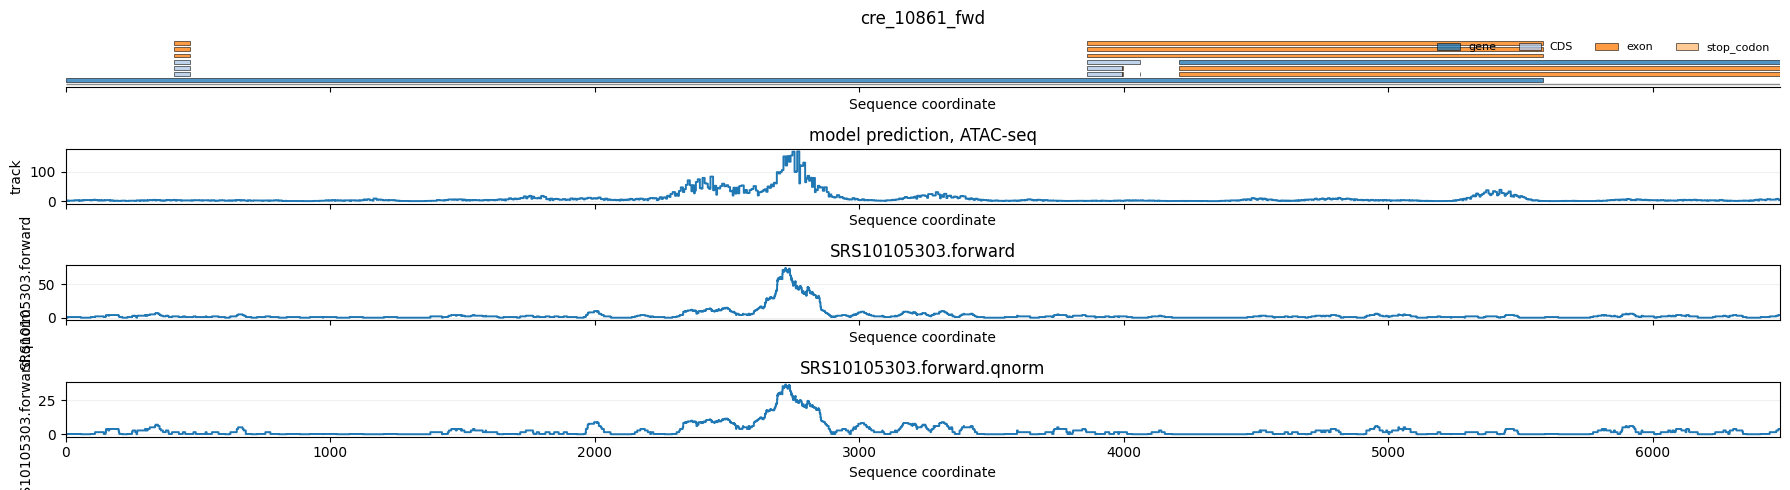

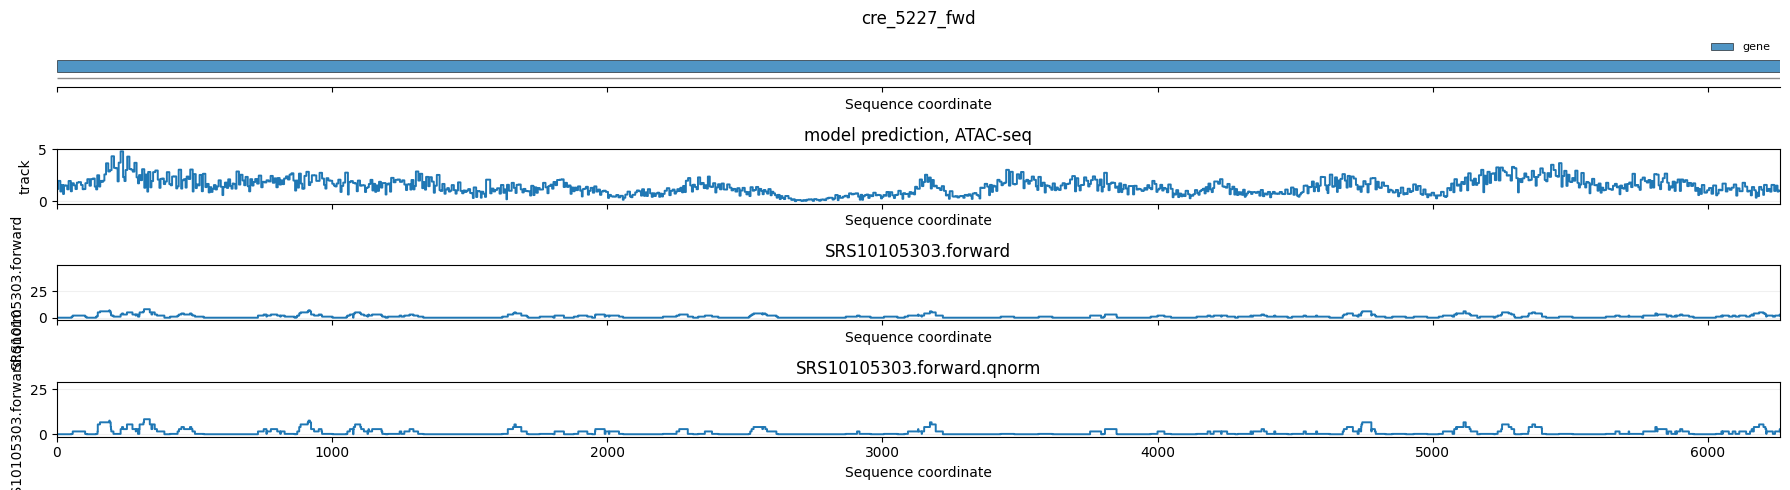

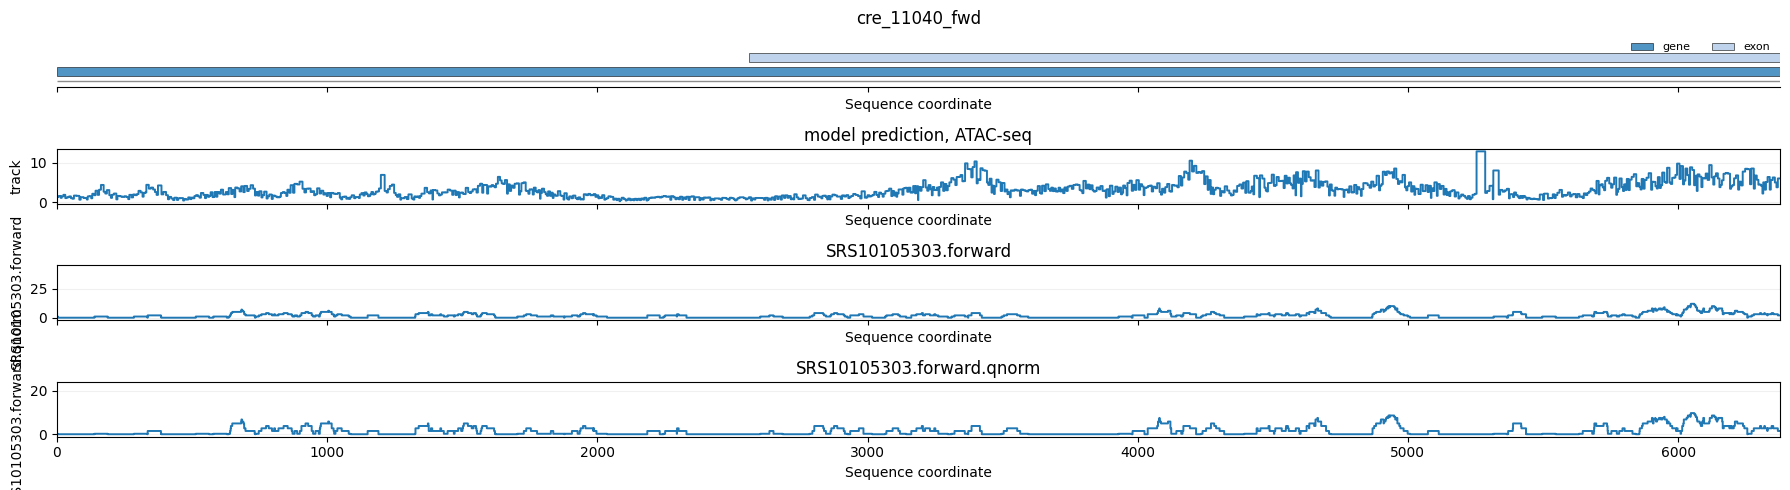

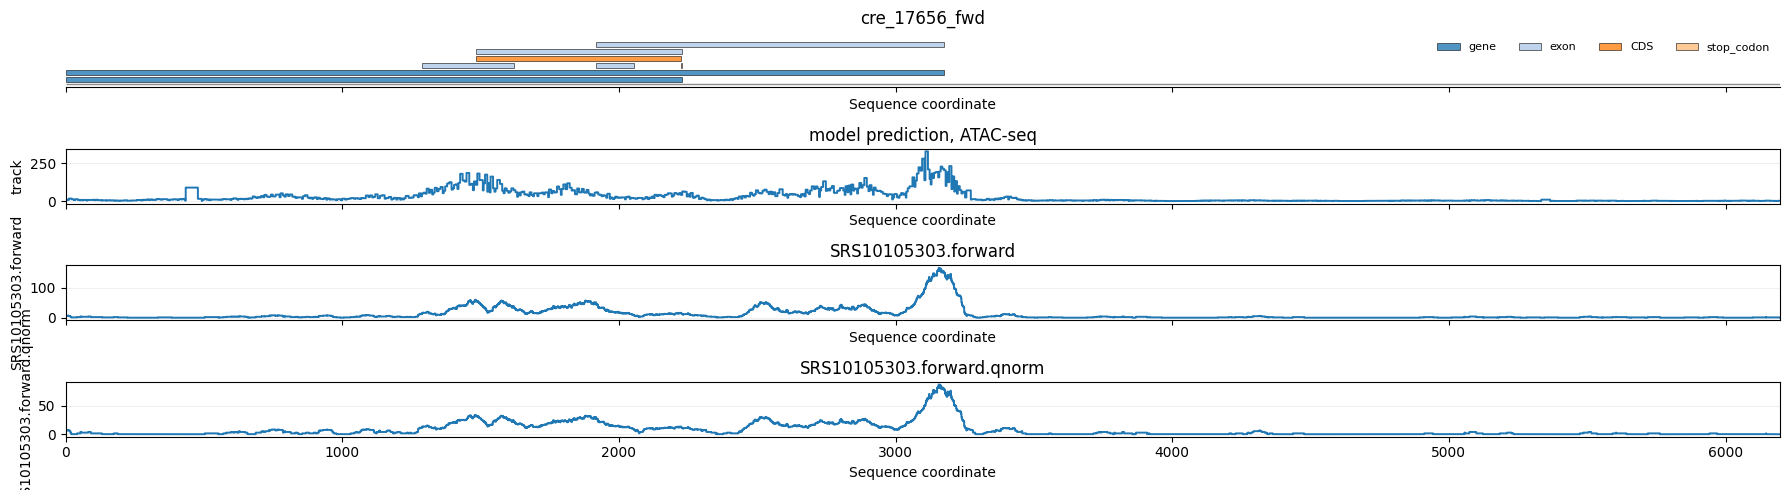

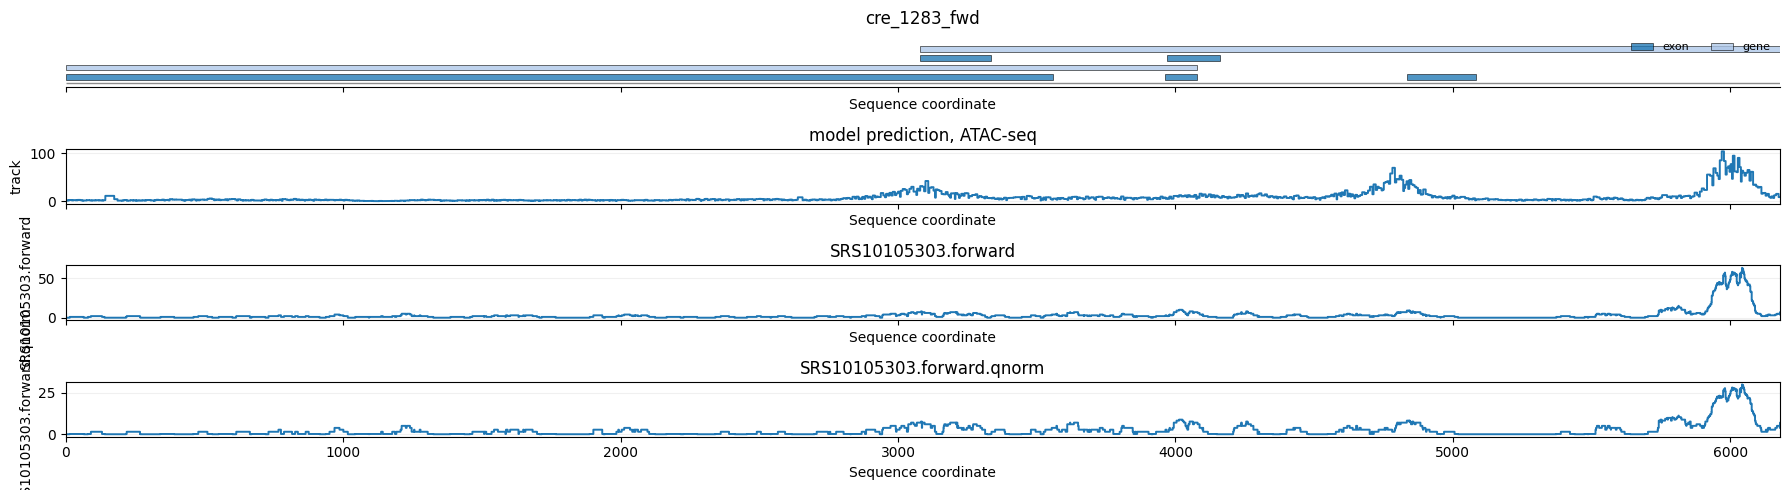

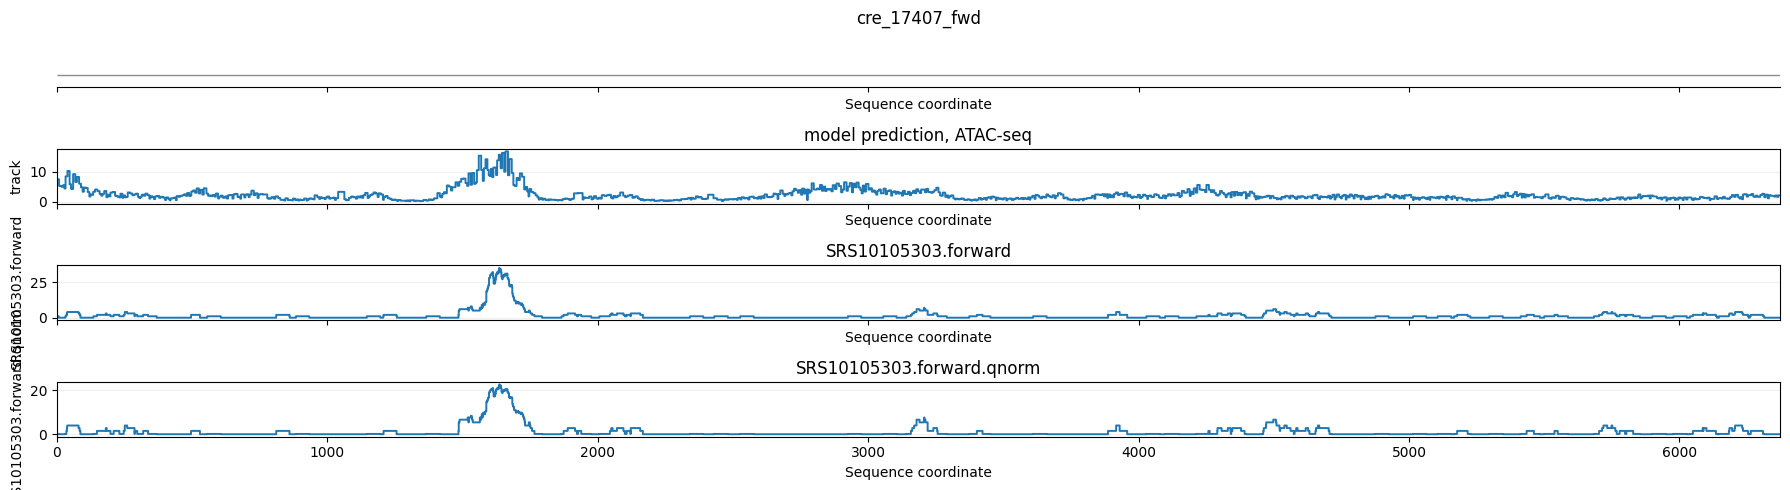

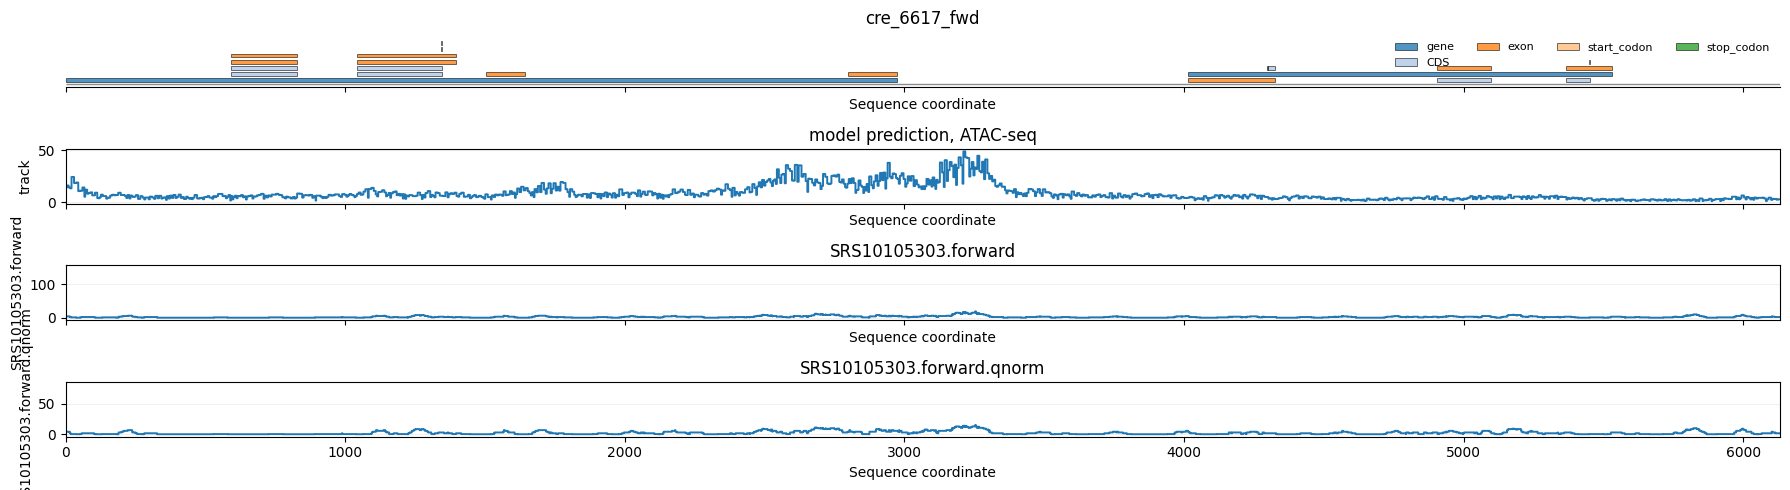

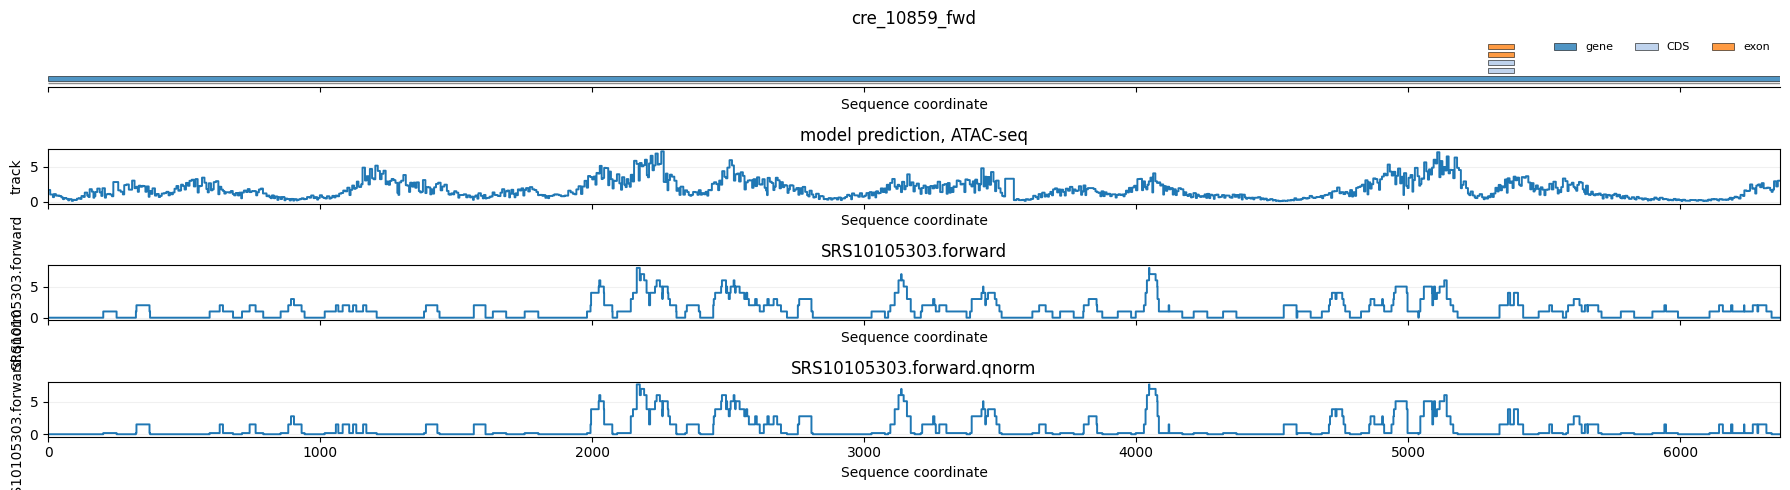

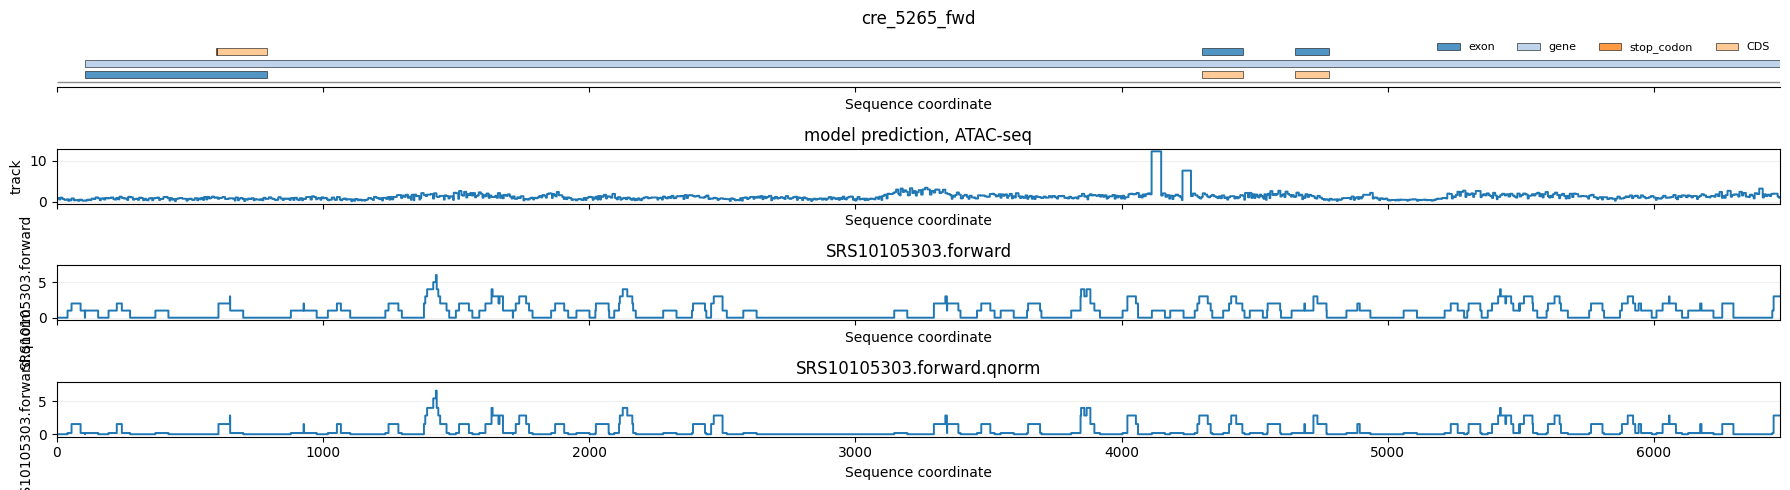

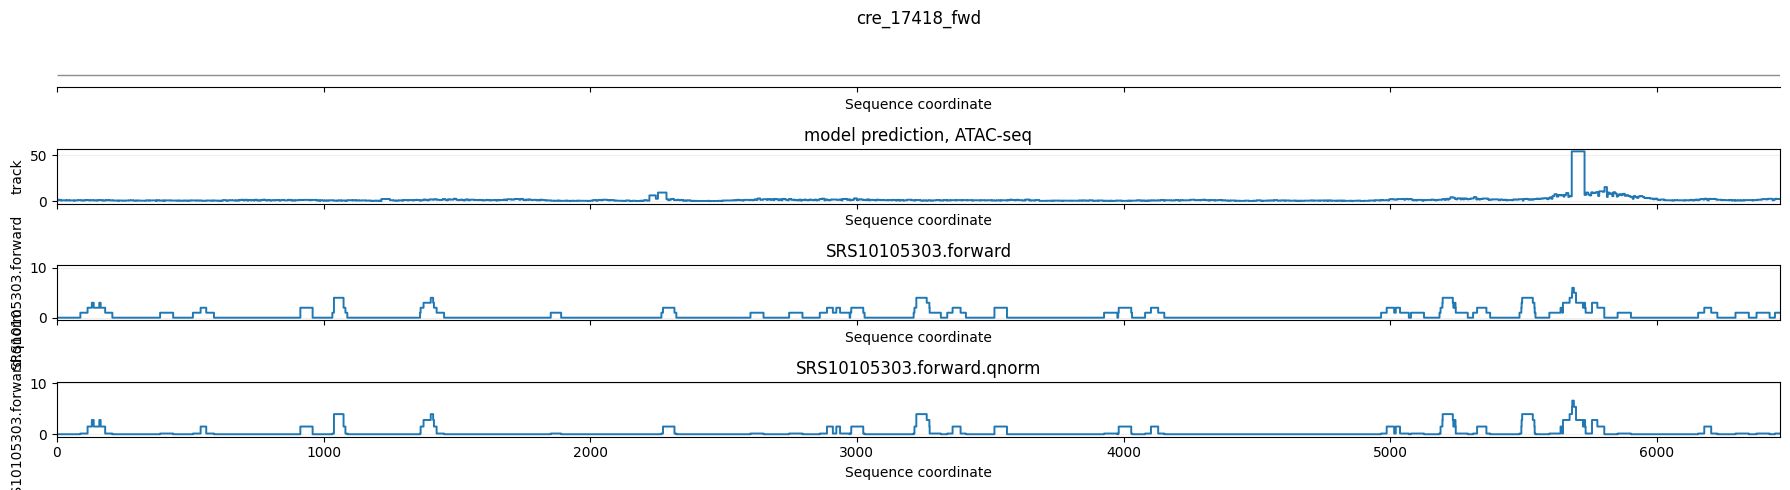

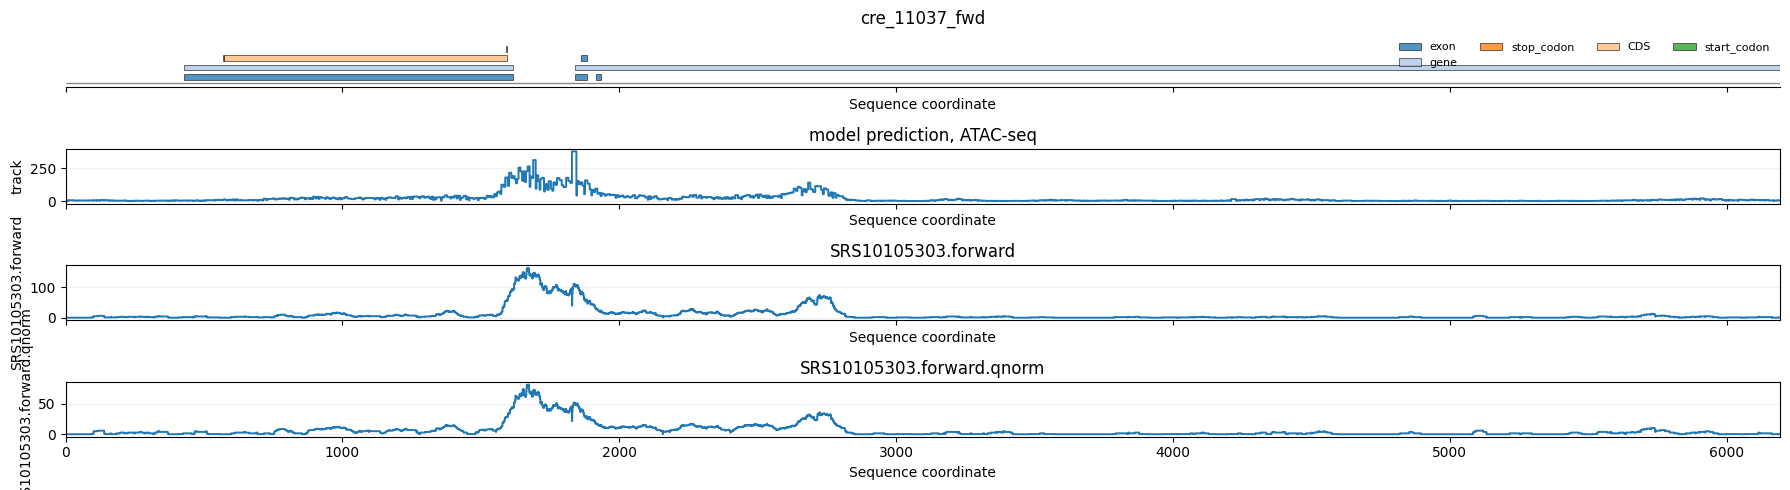

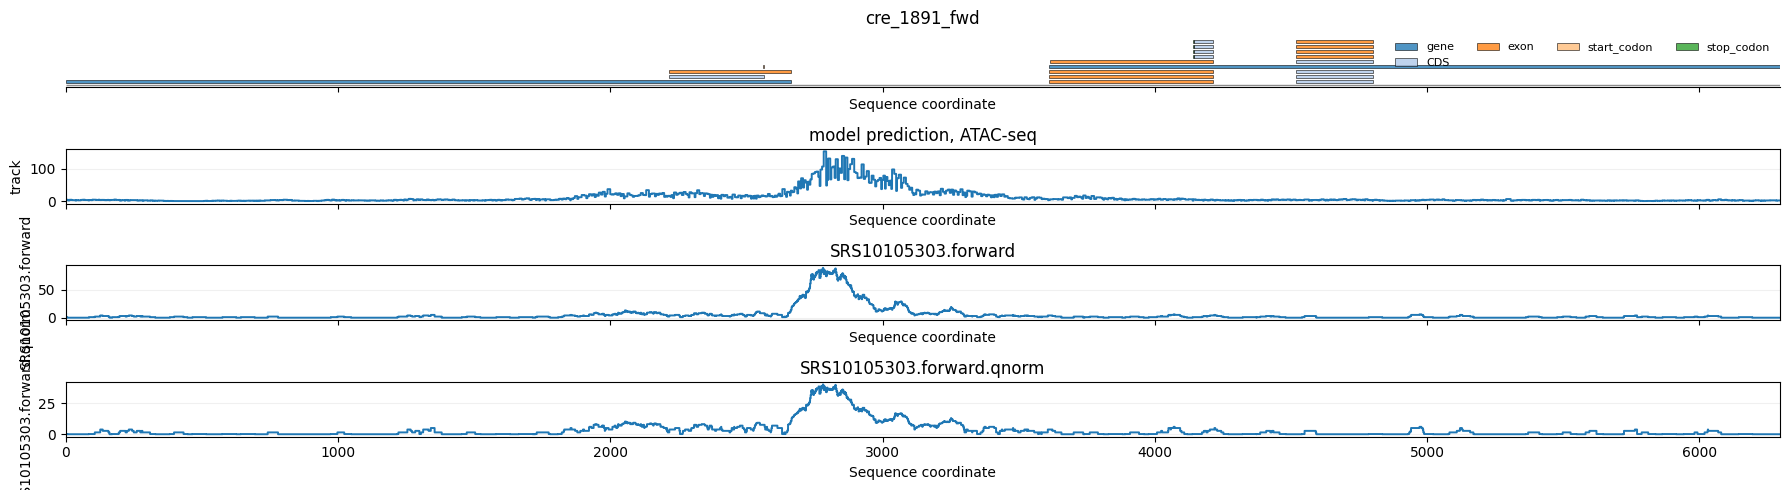

In [110]:
for sequence, (gene, (chrom, tss, tes, strand)) in zip(sequences, tss_tes_coords_top_10.items()):
    prediction = model.predict_sequence(sequence=sequence, center=0, condition=description)

    reference = Track.from_bw(path=bw_forward,
                chrom=chrom,
                center=tss + 5_000,
                size=10_000,
                missing_value=0)
    reference_qnorm = Track.from_bw(path=bw_forward_qnorm,
                chrom=chrom,
                center=tss + 5_000,
                size=10_000,
                missing_value=0)
    
    
    fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(18, 5), sharex=True)
    sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'genome_interval'), label_features=False)
    prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
    reference.plot(color_by_sign=False, ax=axs[2])
    reference_qnorm.plot(color_by_sign=False, ax=axs[3])
    plt.show()
    plt.close()

In [76]:
prediction = model.predict_sequence(sequence=sequences[0], center=0, condition=description)

reference = Track.from_bw(path=bw_forward,
              chrom='NC_086032.1',
              center=12073355 + 5_000,
              size=10_000,
              missing_value=0)

(<Figure size 1800x500 with 3 Axes>,
 <Axes: title={'center': 'SRS10105303.forward'}, xlabel='Sequence coordinate', ylabel='SRS10105303.forward'>)

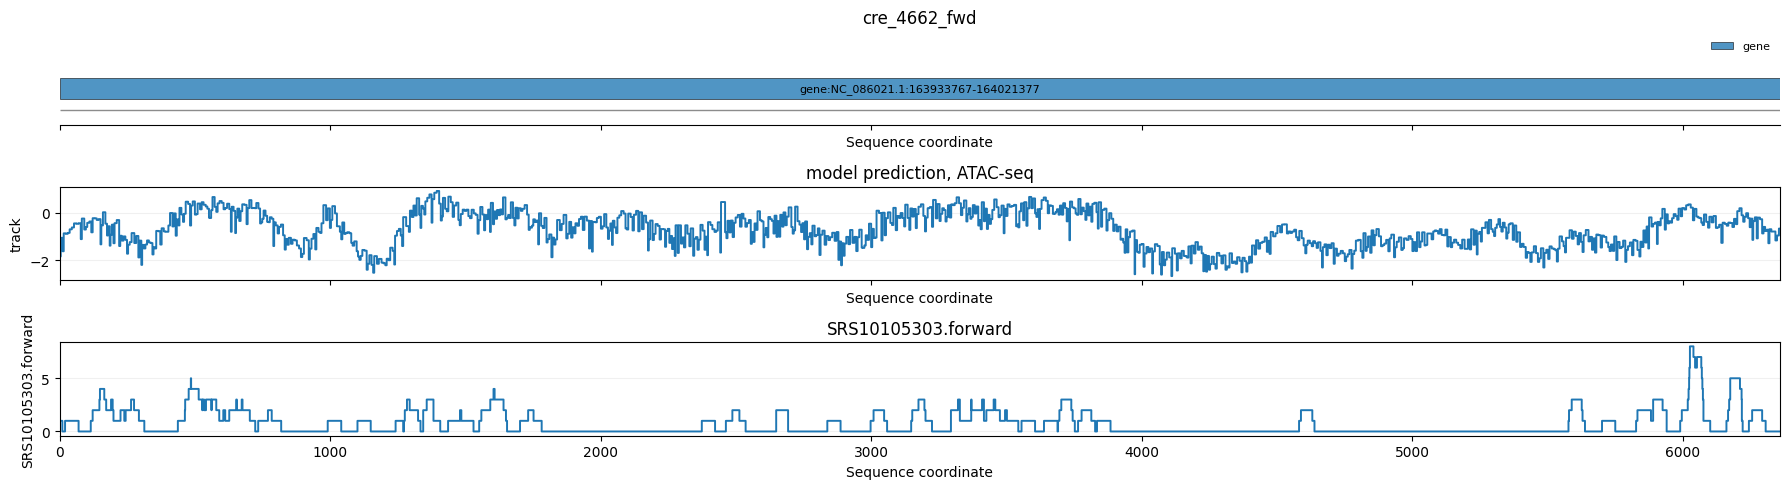

In [77]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'genome_interval'))
prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
reference.plot(color_by_sign=False, ax=axs[2])

Monopterus_albus

In [93]:
BASE_DIR = Path('/home/jovyan/estsoi/SRS24980001')

intervals_forward = pl.read_csv(BASE_DIR / 'Monopterus_albus_forward.csv').sort('cre_prob', descending=True)
intervals_reverse = pl.read_csv(BASE_DIR / 'Monopterus_albus_reverse.csv').sort('cre_prob', descending=True)
bw_forward = BASE_DIR / 'SRS24980001.forward.bw'
bw_reverse = BASE_DIR / 'SRS24980001.reverse.bw'
bw_forward_qnorm = BASE_DIR / 'SRS24980001.forward.qnorm.bw'
bw_reverse_qnorm = BASE_DIR / 'SRS24980001.reverse.qnorm.bw'
description = json.load(
                            open(BASE_DIR / 'SRS24980001.json', 'r')
                        )
genome_fasta = BASE_DIR / 'Monopterus_albus.fasta'
genome_annotation = BASE_DIR / 'GCF_001952655.1_M_albus_1.0_genomic.gtf.gz'

In [94]:
genome = Genome(fasta_path = genome_fasta, annotation=genome_annotation)

/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/dna/genome.py:437: RuntimeWarning: Creating tabix index for annotation /home/jovyan/estsoi/SRS24980001/GCF_001952655.1_M_albus_1.0_genomic.gtf.gz. debug={'compressed_path': '/home/jovyan/estsoi/SRS24980001/GCF_001952655.1_M_albus_1.0_genomic.gtf.gz', 'tbi_path': '/home/jovyan/estsoi/SRS24980001/GCF_001952655.1_M_albus_1.0_genomic.gtf.gz.tbi', 'csi_path': '/home/jovyan/estsoi/SRS24980001/GCF_001952655.1_M_albus_1.0_genomic.gtf.gz.csi'}
  return _TabixGtfAnnotation(cls._ensure_tabix_gtf(path))
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/dna/genome.py:505: RuntimeWarning: Could not index the provided annotation, likely because it is unsorted; sorting with Polars and writing a sorted bgzipped copy. debug={'compressed_path': '/home/jovyan/estsoi/SRS24980001/GCF_001952655.1_M_albus_1.0_genomic.gtf.gz', 'sorted_path': '/home/jovyan

In [96]:
top_10 = intervals_forward.head(30)
middle_10 = intervals_forward[len(intervals_forward)//2-7000-5:len(intervals_forward)//2-7000+5, :]
bottom_10 = intervals_forward.tail(10)

In [97]:
tss_tes_coords_top_10 = {row['gene_id'] : (row['chromosome'], row['TSS'], row['TES'], '+') for row in top_10.iter_rows(named=True)}

In [98]:
results = []

sequences = []
for gene, (chrom, tss, tes, strand) in tss_tes_coords_top_10.items():
    sequence = genome.sequence(
            chrom=chrom,
            start=tss,
            end=tes,
            strand=strand,
            include_features=True,
            name=gene,
        )
    sequences.append(sequence)

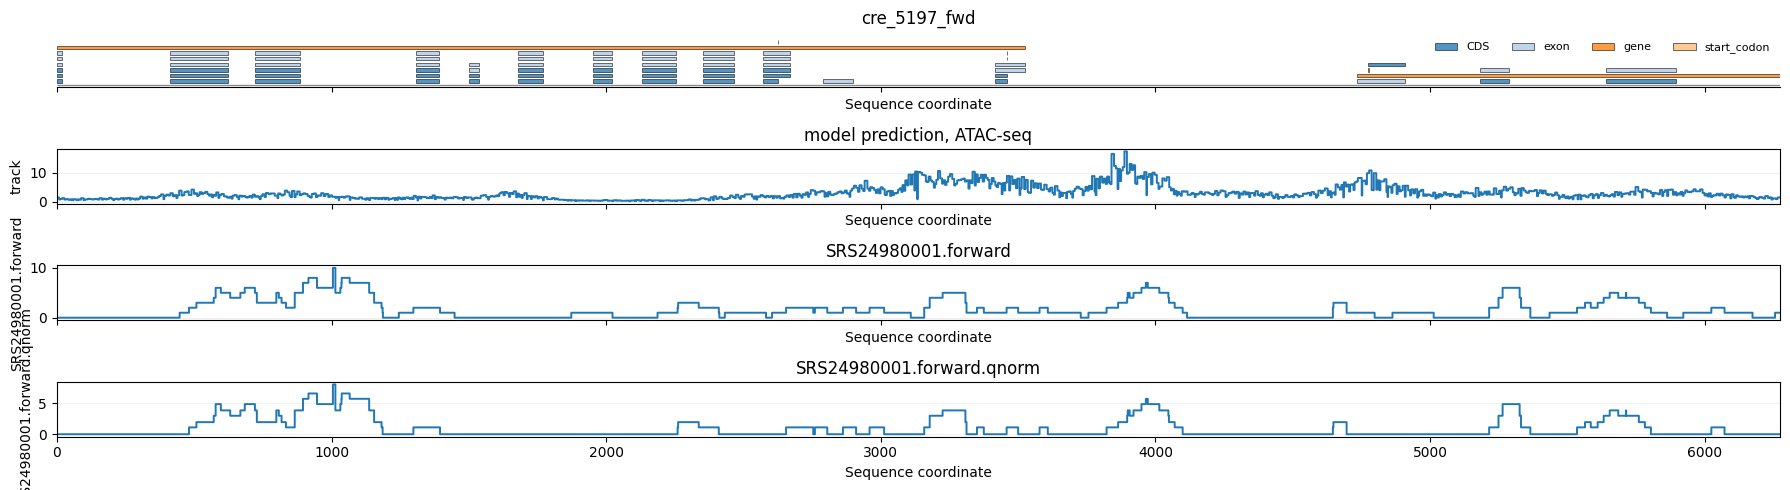

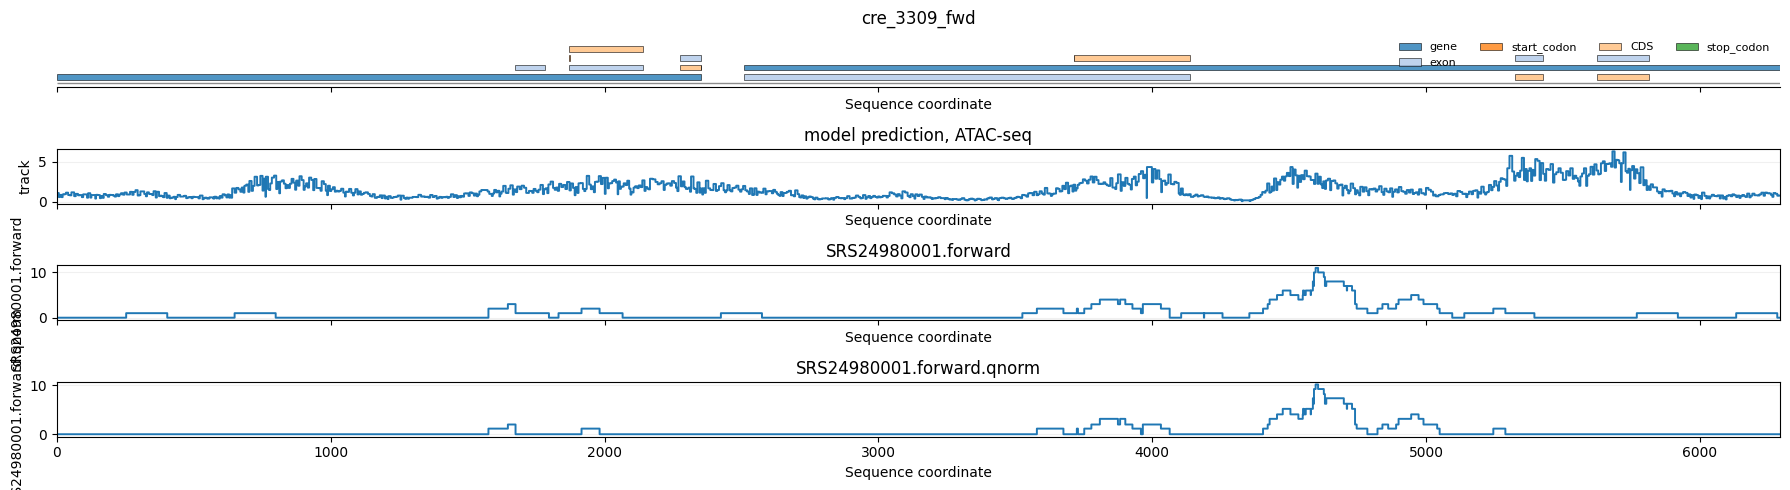

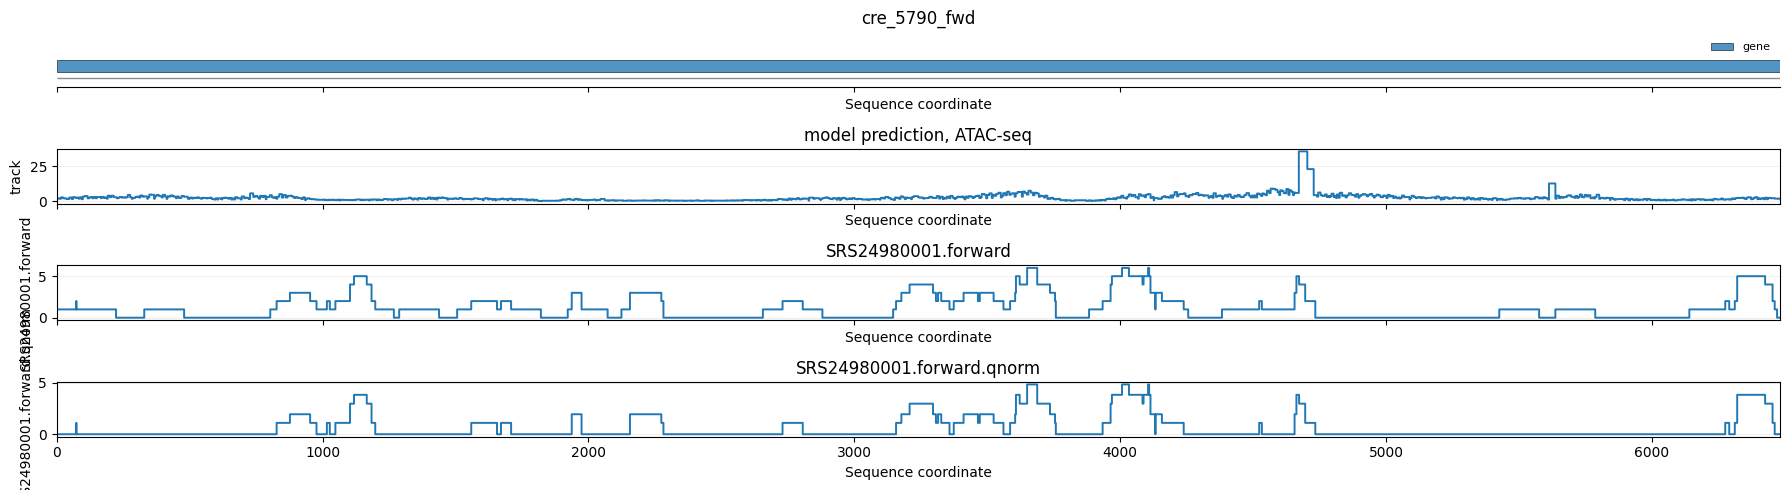

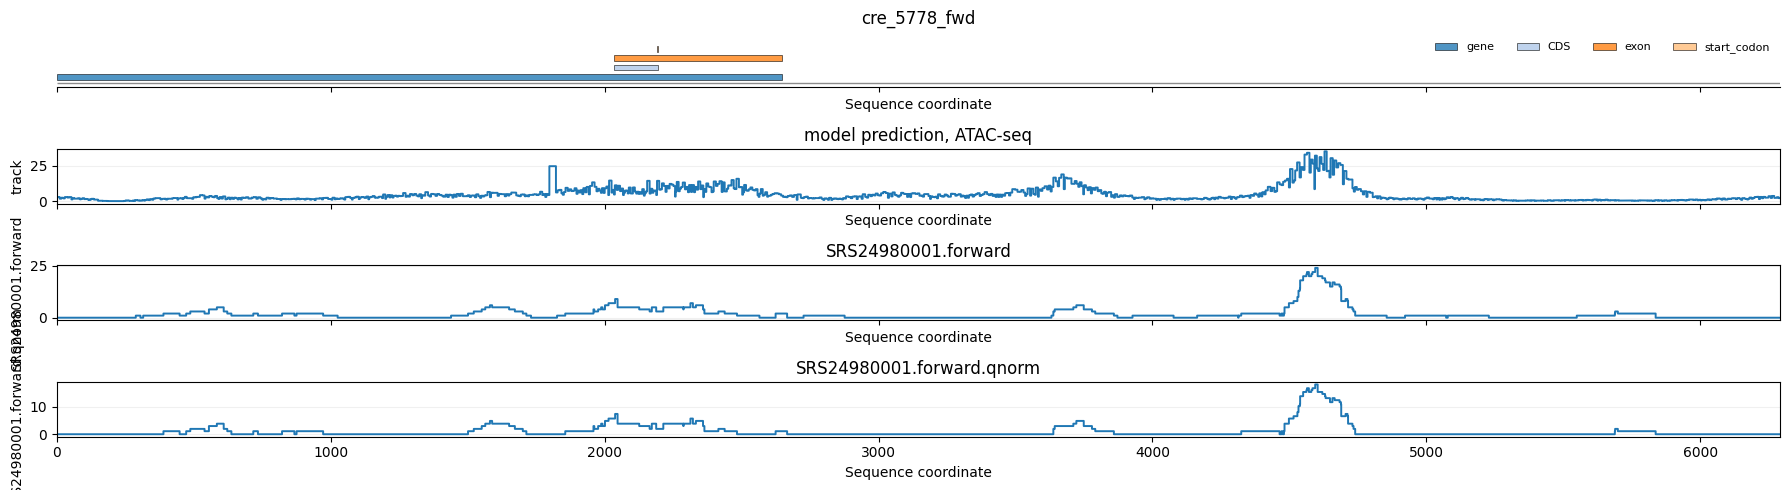

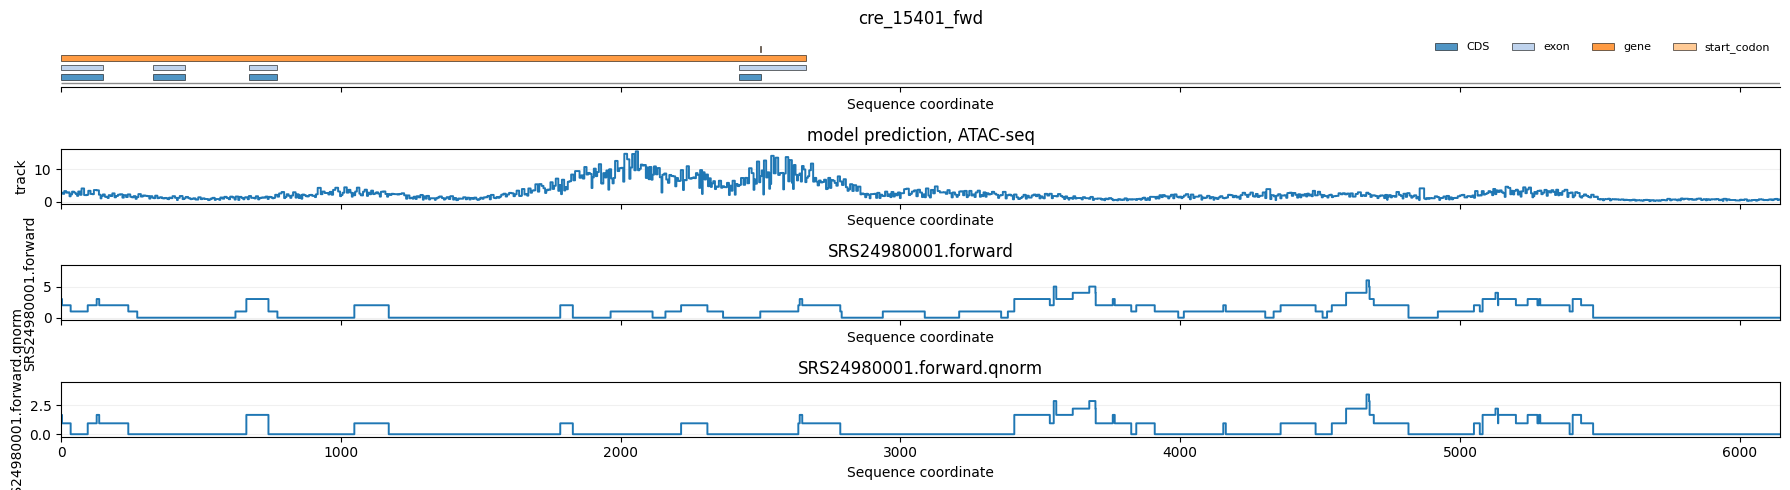

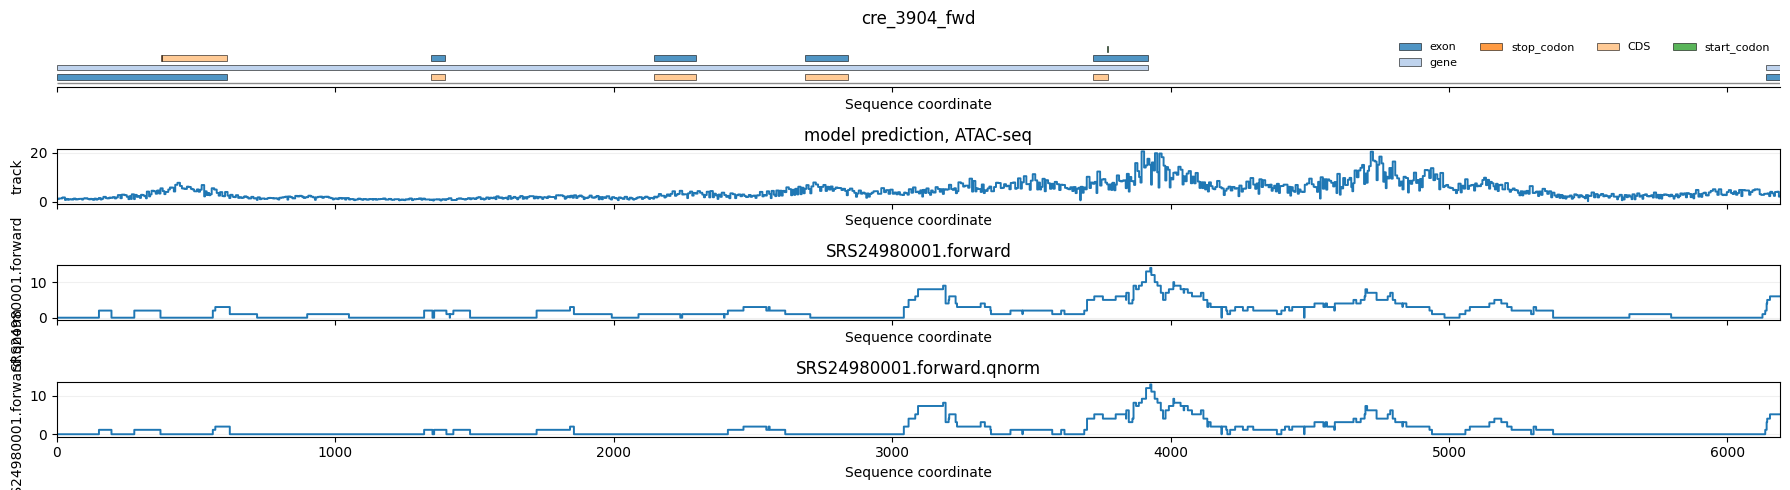

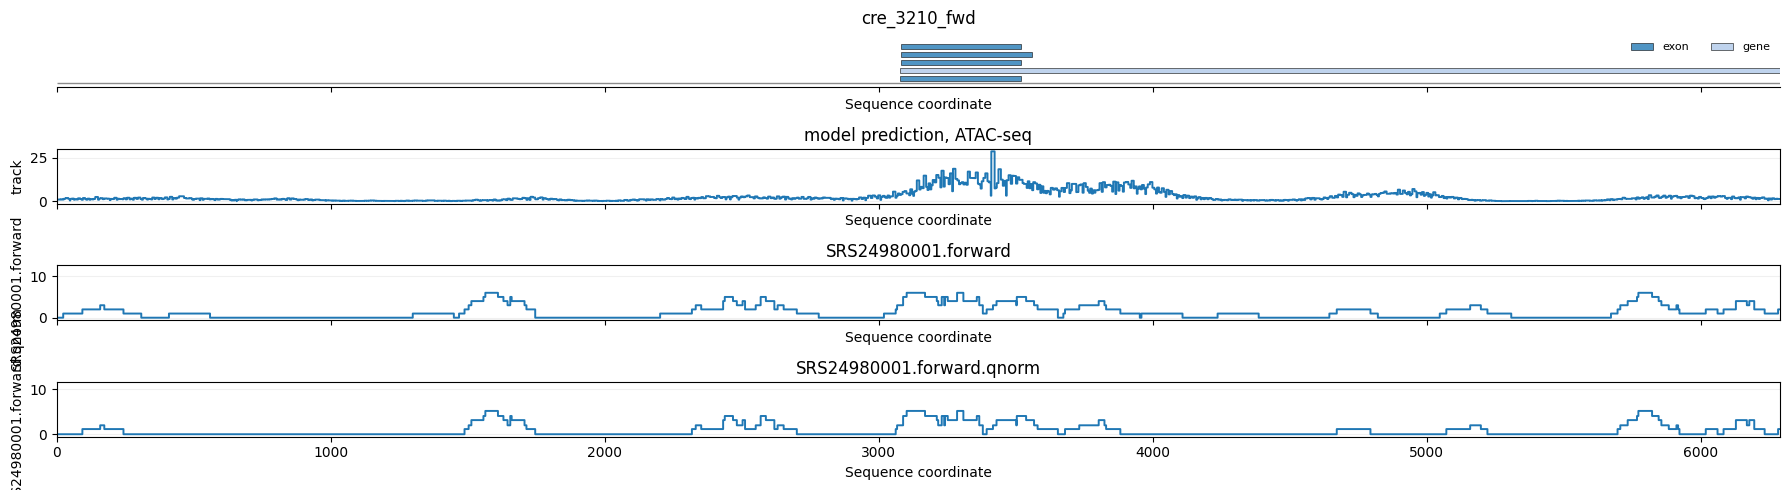

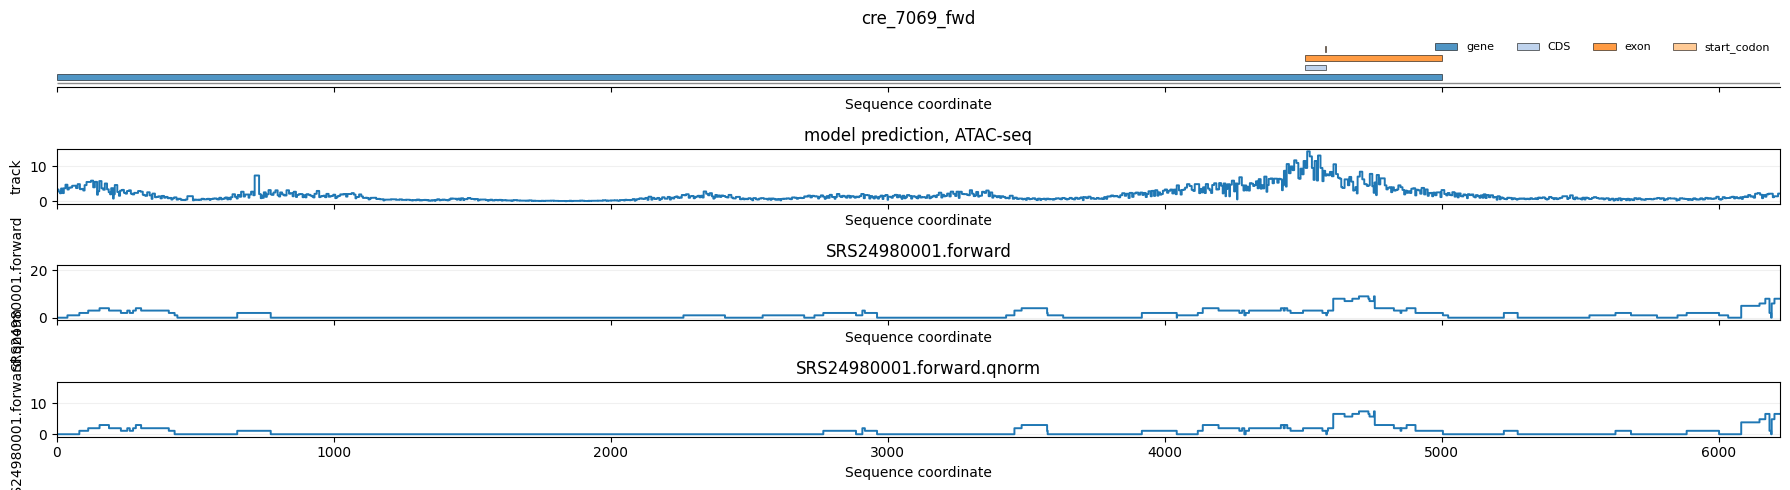

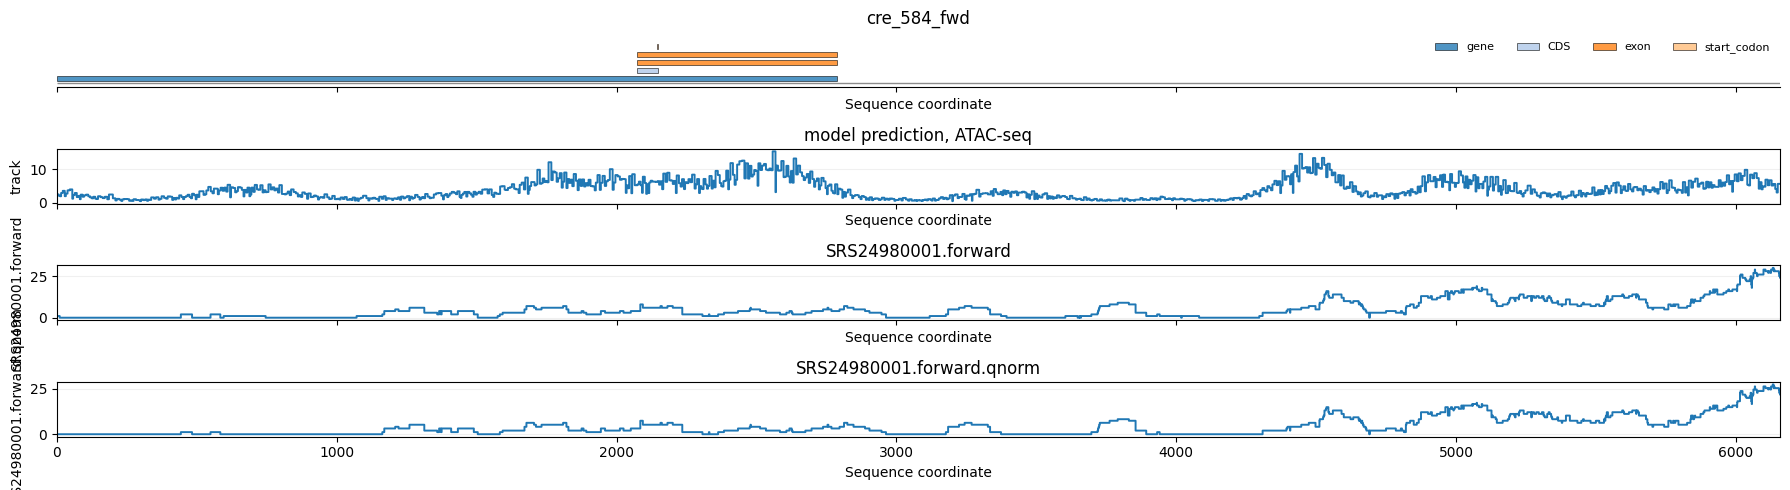

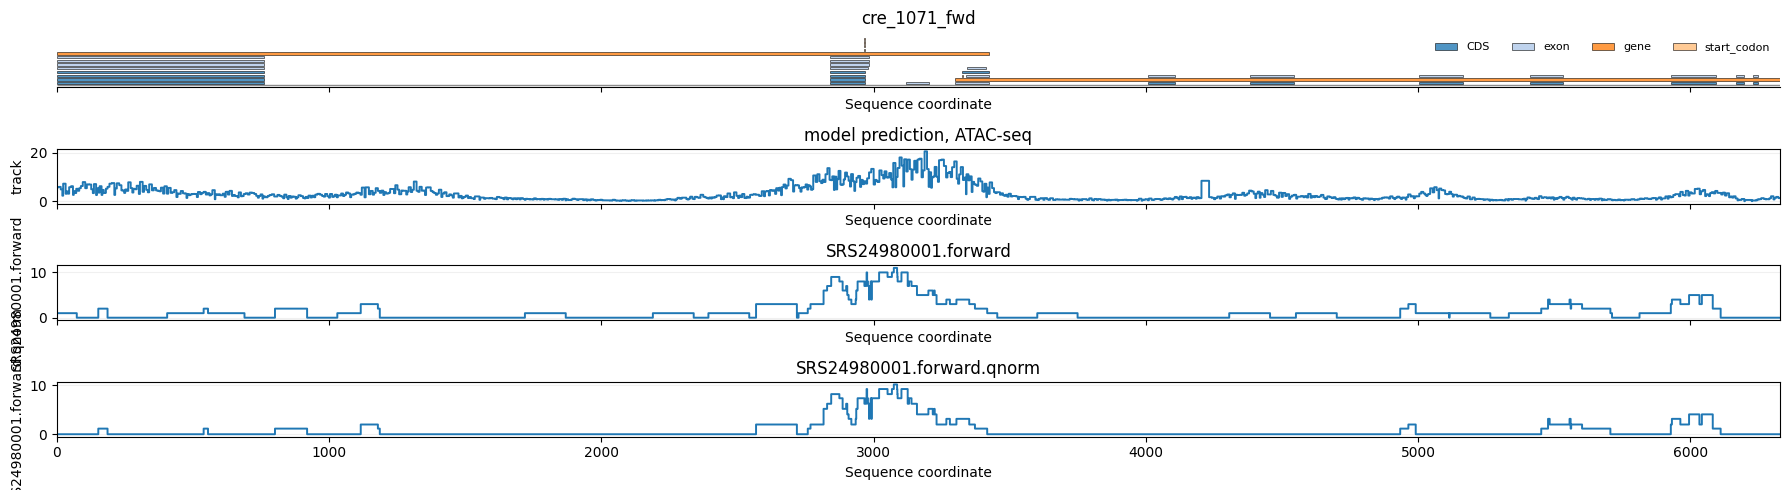

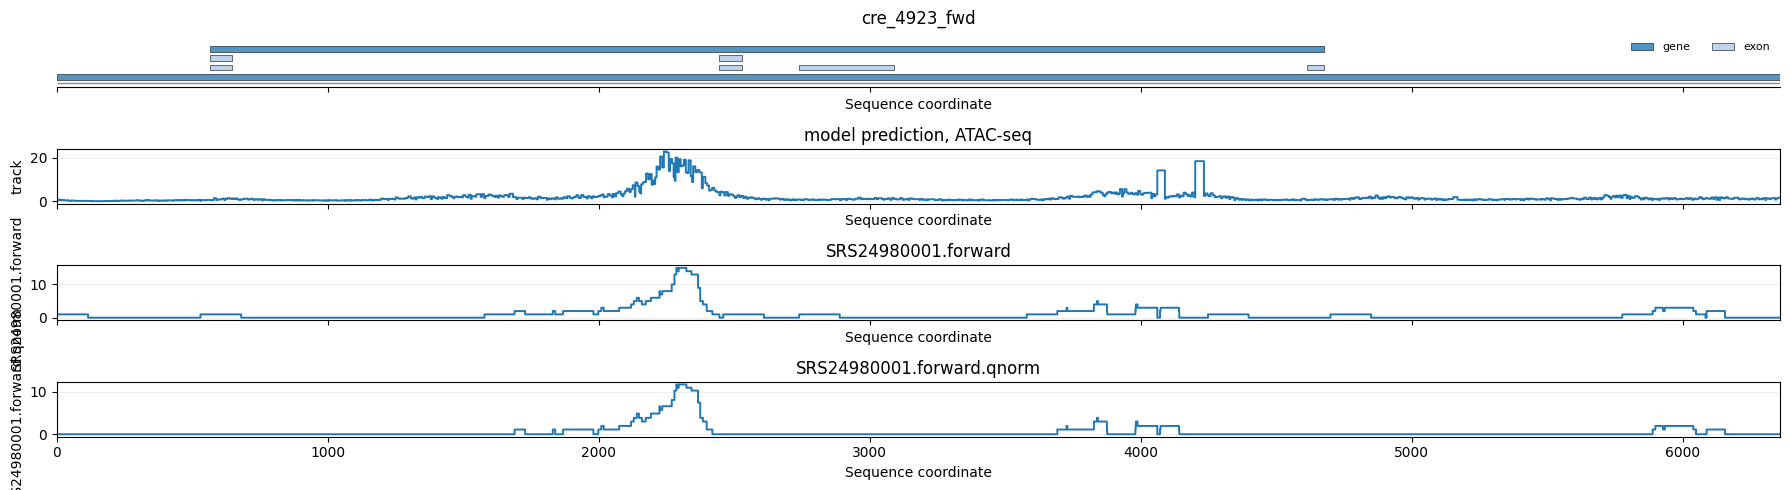

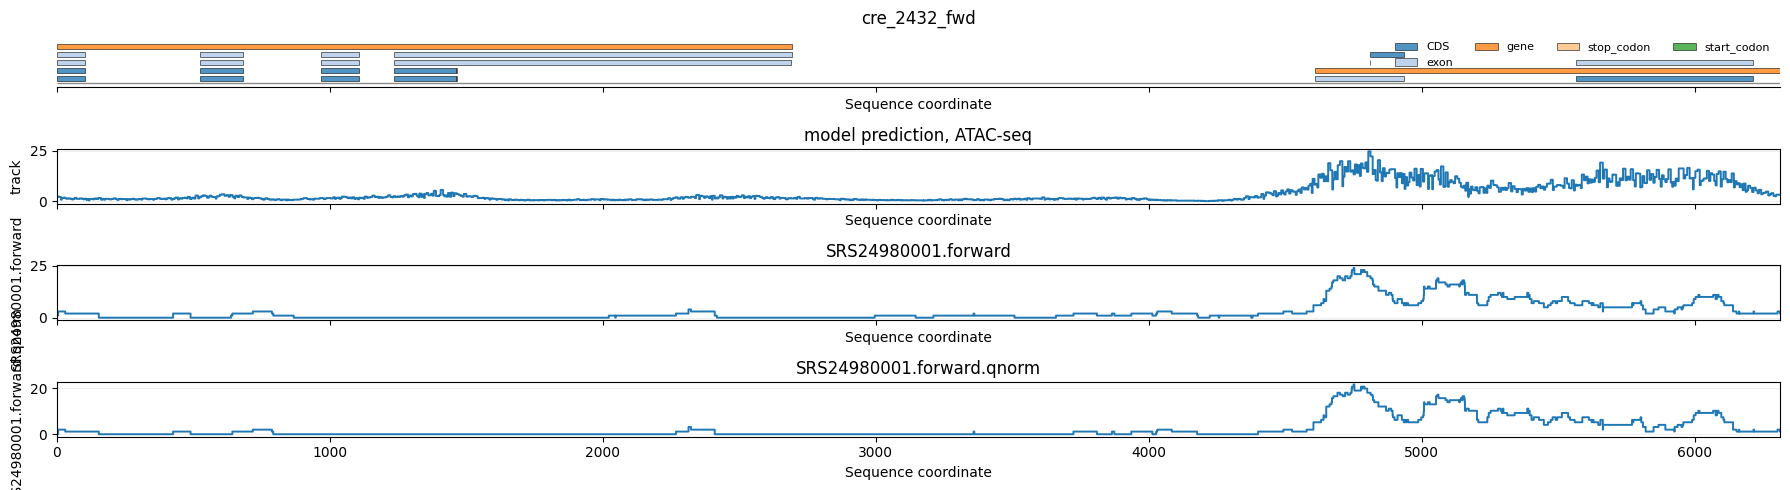

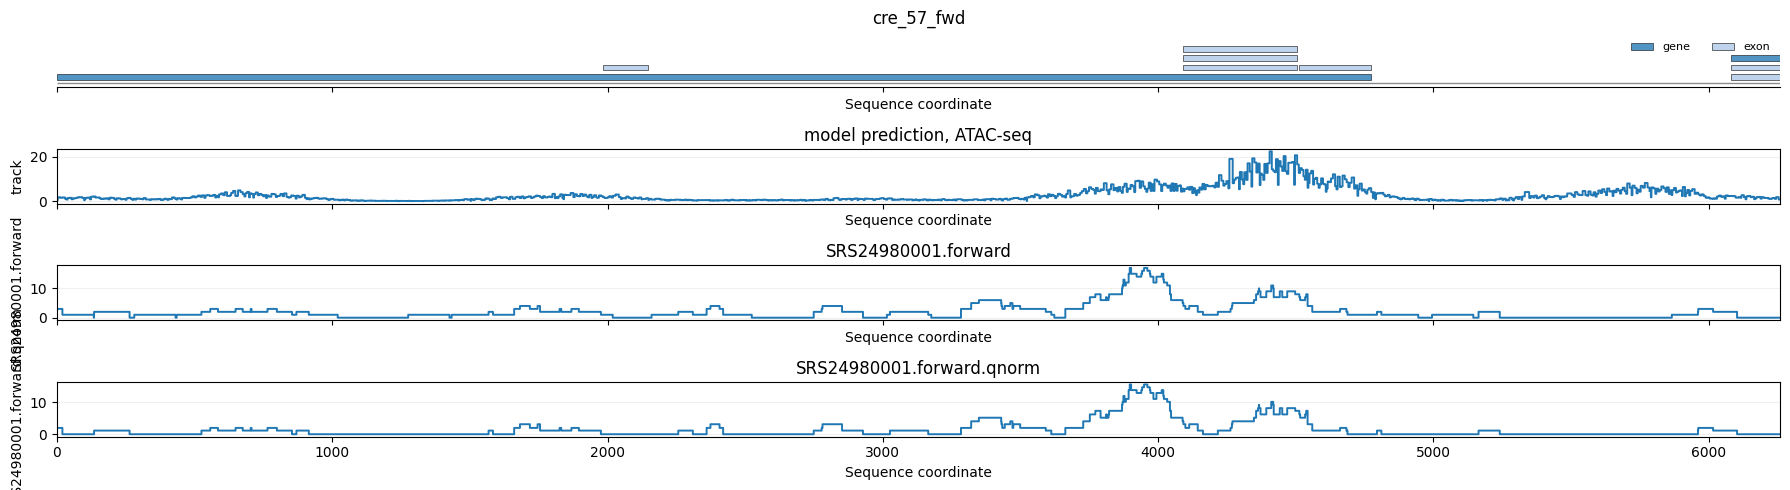

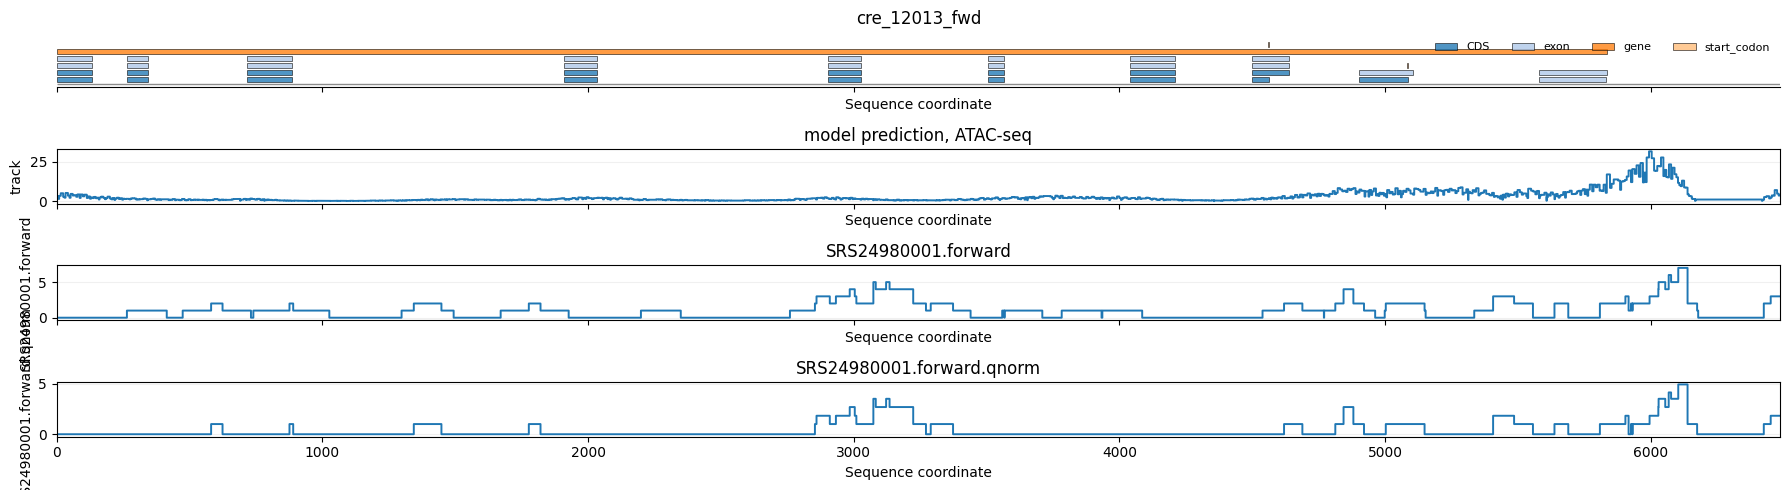

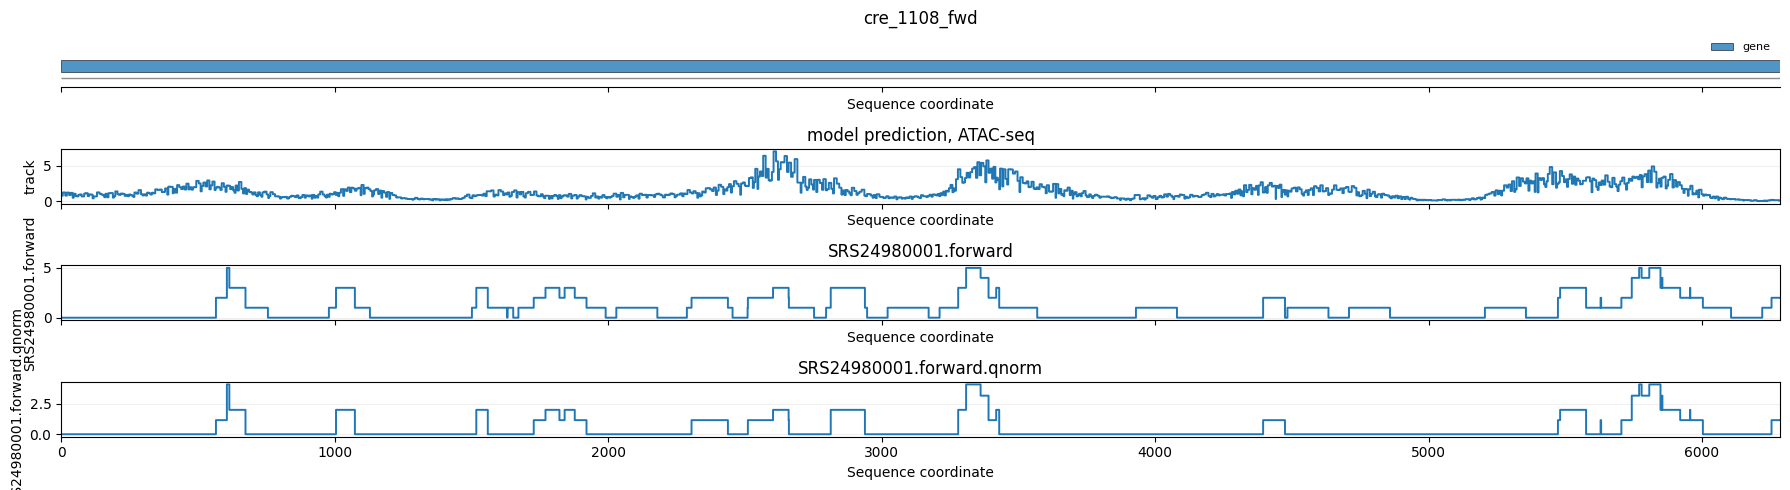

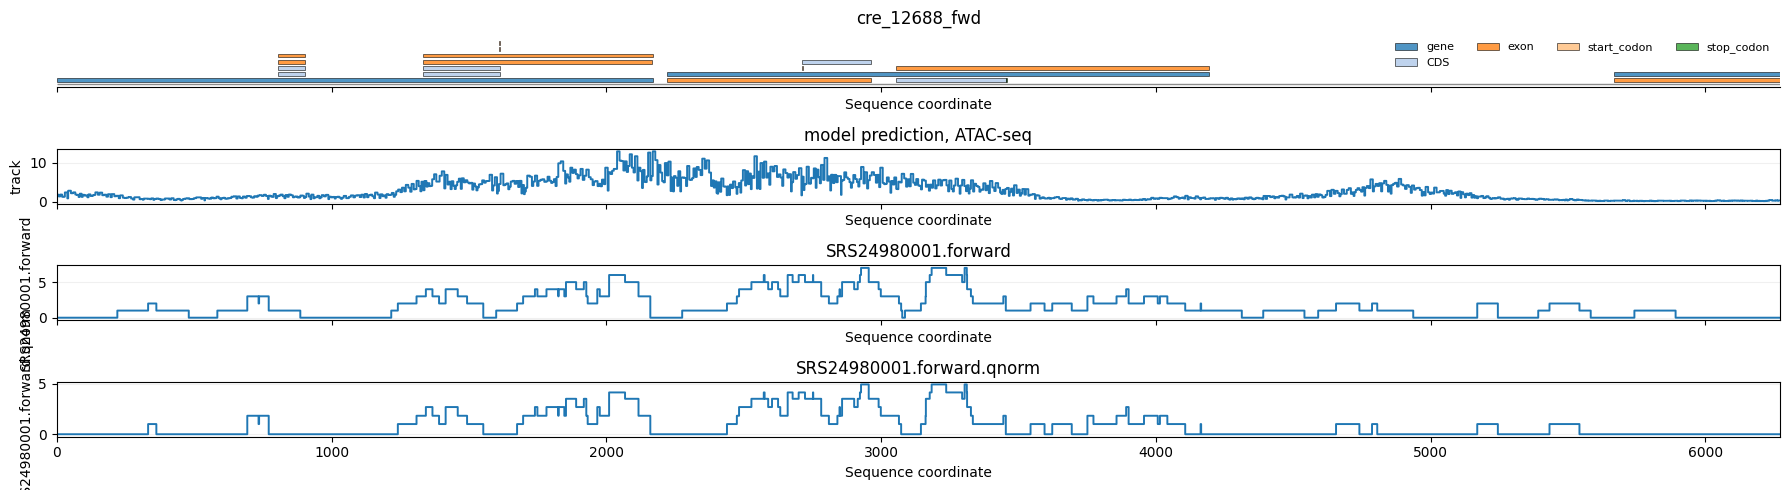

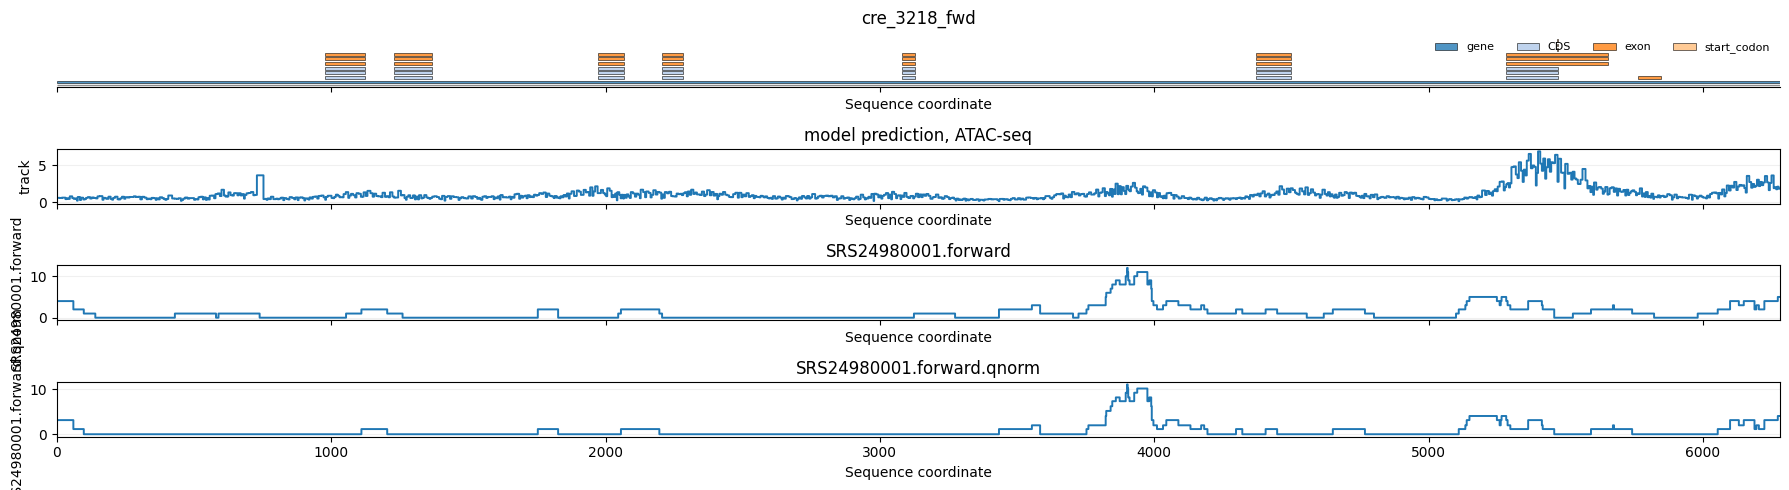

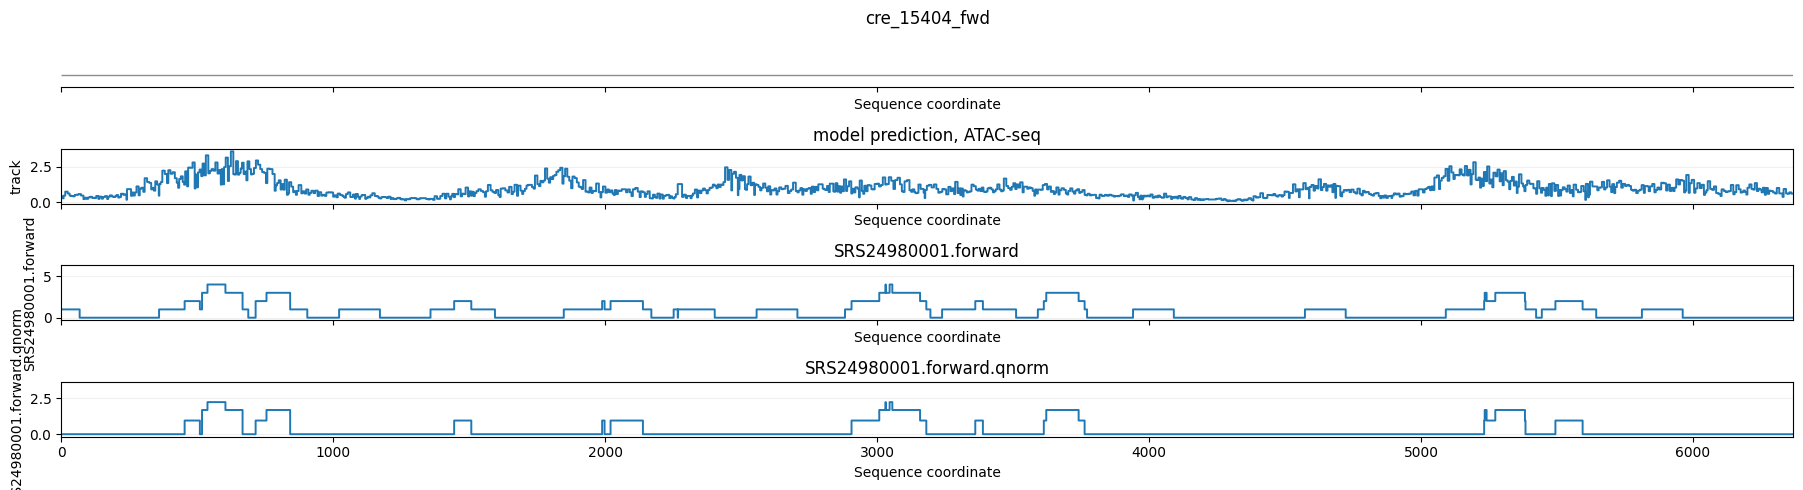

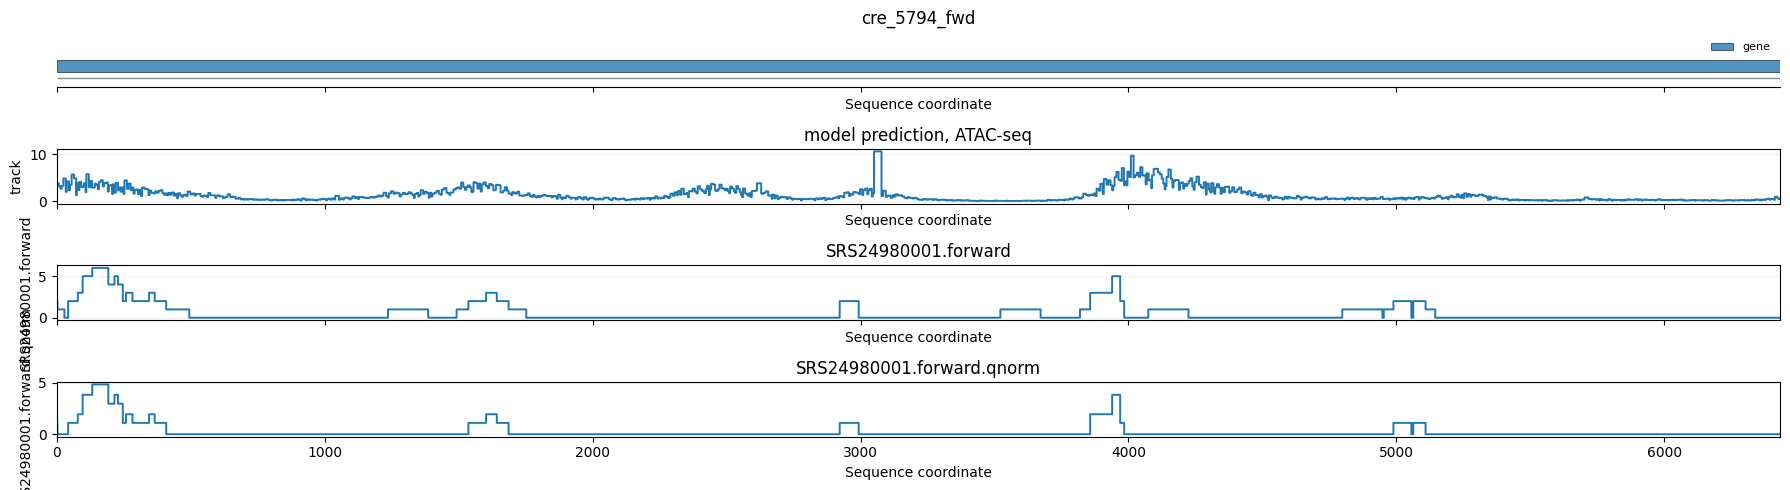

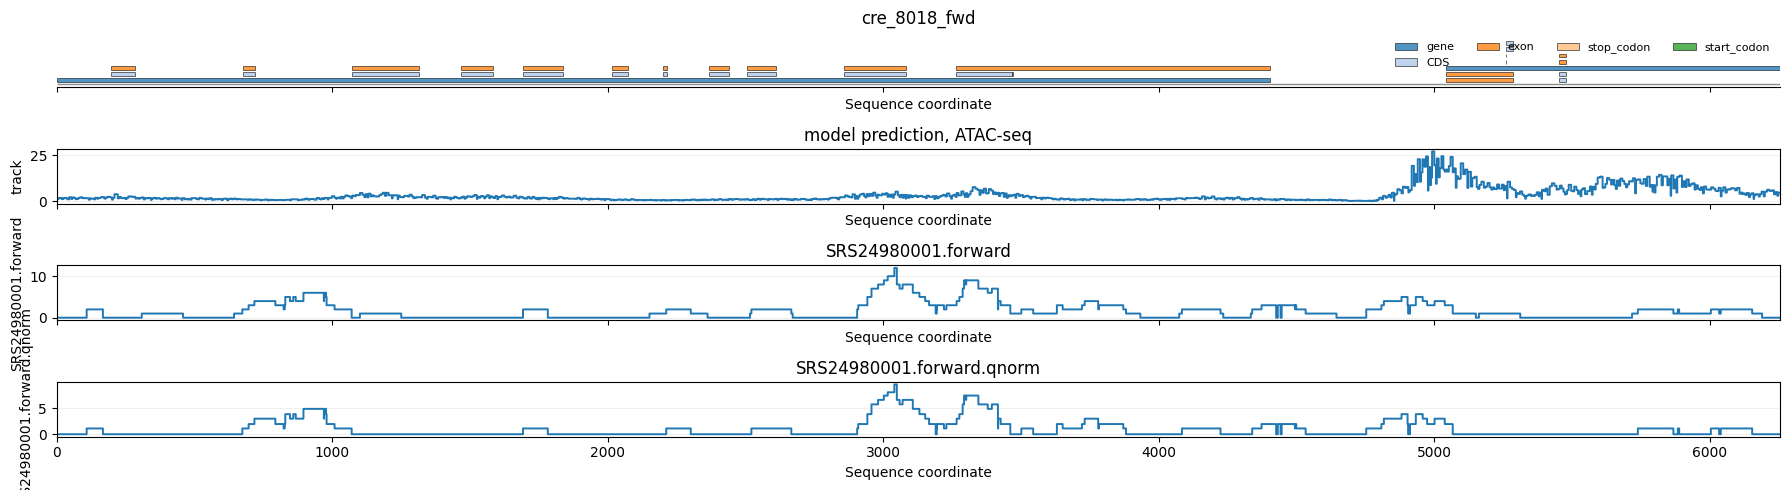

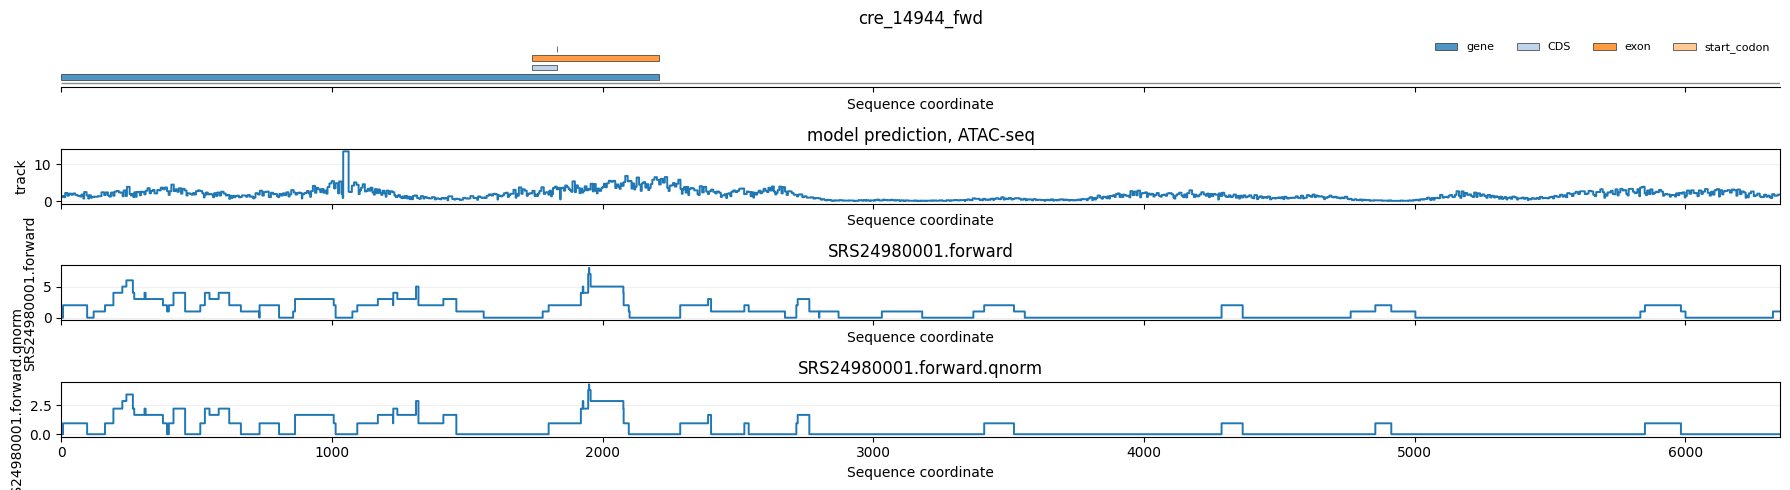

ValueError: Requested interval NW_018128369.1:140338-150338 exceeds chromosome length 150239.

In [103]:
for sequence, (gene, (chrom, tss, tes, strand)) in zip(sequences, tss_tes_coords_top_10.items()):
    prediction = model.predict_sequence(sequence=sequence, center=0, condition=description)

    reference = Track.from_bw(path=bw_forward,
                chrom=chrom,
                center=tss + 5_000,
                size=10_000,
                missing_value=0)
    reference_qnorm = Track.from_bw(path=bw_forward_qnorm,
                chrom=chrom,
                center=tss + 5_000,
                size=10_000,
                missing_value=0)
    
    
    fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(18, 5), sharex=True)
    sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'genome_interval'), label_features=False)
    prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
    reference.plot(color_by_sign=False, ax=axs[2])
    reference_qnorm.plot(color_by_sign=False, ax=axs[3])
    plt.show()
    plt.close()